<div dir="rtl">

# מטלת חיזוי דירוגי סרטים
## מגישים

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>שם מלא</th><th>תעודת זהות</th></tr>
</thead>
<tbody>
<tr><td>מאיה הלוי</td><td>הת"ז בקובץ טקסט בלבד בגלל שהגיט ציבורי</td></tr>
<tr><td>עידן וידר</td><td>הת"ז בקובץ טקסט בלבד בגלל שהגיט ציבורי</td></tr>
</tbody>
</table>
<div dir="rtl">
    
## תיאור המטלה
<div dir="rtl">
בפרויקט זה אנו בונים מודל לחיזוי דירוגי סרטים (`averageRating`) על בסיס מידע שזמין לפני שחרור הסרט - שנה, משך, ז'אנר, שחקנים, במאי, מדינה ושפה.
<div dir="rtl">
המטרה: לפתח מודל רגרסיה שלם הכולל הנדסת פיצ'רים, אימון, הערכה, וניתוח טעויות.
<div dir="rtl">
    
## מבנה ההגשה
<div dir="rtl">
    
1. **הכנת הנתונים** - פונקציית `prepare_data` עם הנדסת 18 פיצ'רים
2. **בניית Pipeline** - טיפול מובנה במניעת data leakage
3. **אימון 2 מודלים** - Elastic Net ו-Random Forest
4. **הערכה** - 10-Fold CV + Test Set
5. **ניתוח טעויות** - בחינת outliers וביצועים לפי קבוצות
6. **בדיקת הוגנות** - ביצועי המודל לפי ז'אנר ועשור
7. **חשיבות פיצ'רים** - אילו פיצ'רים תרמו הכי הרבה

</div>

<div dir="rtl">

## ייבוא ספריות

### ספריות בסיסיות

- **`os`, `re`, `ast`, `pickle`** – ספריות סטנדרטיות של Python לעבודה עם קבצים, ביטויים רגולריים, פענוח מחרוזות, ושמירה/טעינה של קבצי קאש.
- **`warnings`** – לשליטה בהצגת אזהרות במהלך הריצה.
- **`gzip`** – פתיחת קבצי IMDb הדחוסים (`.tsv.gz`).
- **`requests`** – שליחת בקשות HTTP ל-Wikidata API לקבלת נתוני אוסקרים.
- **`time`** – מדידת זמנים והשהיות בין קריאות API.
- **`collections.defaultdict`, `Counter`** – מבני נתונים יעילים לספירות וצבירת ערכים.

### ספריות לעבודה עם דאטה

- **`numpy`** – חישובים מתמטיים, פעולות על מערכים, ממוצעים וסטיות תקן.
- **`pandas`** – עבודה עם טבלאות נתונים (DataFrames), קריאת CSV, מניפולציות על עמודות.

### ספריות לויזואליזציה

- **`matplotlib.pyplot`** – יצירת גרפים 
.
- **`seaborn`** – גרפים סטטיסטיים מבוססת על matplotlib.

### בניית Pipeline

- **`Pipeline`** – מאחד את שלבי עיבוד הדאטה והאימון של המודל למבנה אחד, מונע data leakage בעת ביצוע Cross-Validation.
- **`ColumnTransformer`** – מאפשר טיפול שונה בעמודות שונות (למשל, סקיילינג לעמודות נומריות ו-OneHotEncoder לעמודות קטגוריאליות).

### עיבוד מקדים

- **`OneHotEncoder`** – הופך עמודות קטגוריאליות (כגון Country, Language) לעמודות בינאריות.
- **`StandardScaler`** – מנרמל עמודות נומריות (ממוצע 0, סטיית תקן 1), חשוב במיוחד עבור Elastic Net.
- **`SimpleImputer`** – משלים ערכים חסרים (NaN) באמצעות חציון, ממוצע, או הערך השכיח ביותר.
- **`MultiLabelBinarizer`** – המרת עמודות multi-label (genres, Country, Language) לעמודות בינאריות.
- **`PolynomialFeatures`** – יצירת אינטראקציות בין פיצ'רים נומריים (degree=2) למודל הליניארי.

### טרנספורמרים מותאמים

- **`BaseEstimator`, `TransformerMixin`** – מחלקות בסיס מ-Scikit-Learn שאיפשרו לנו ליצור טרנספורמר מותאם אישית (MultiLabelTopN) המשתלב ב-Pipeline.

### מודלים

- **`ElasticNet`** – מודל לינארי שעליו סעיף התחרות.
- **`RandomForestRegressor`** – המודל השני שבחרנו לאמן אותו.

### כלי הערכת מודלים

- **`GridSearchCV`** – חיפוש ממצה (exhaustive) של היפר-פרמטרים על פני רשת ערכים מוגדרת.
- **`cross_validate`** – ביצוע K-Fold Cross-Validation והחזרת מדדים מרובים (RMSE, MAE, R²).
- **`cross_val_predict`** – החזרת תחזיות OOF (Out-of-Fold) לכל סרט – שימושי לניתוח שגיאות.
- **`KFold`** – אובייקט הפיצול ל-K חלקים שווים.
- **`train_test_split`** – חלוקת הדאטה לסט אימון וסט בדיקה.

### מדדי הערכה

- **`mean_squared_error`** – שגיאה ריבועית ממוצעת (MSE), בסיס לחישוב RMSE.
- **`mean_absolute_error`** – שגיאה מוחלטת ממוצעת (MAE).
- **`r2_score`** – מדד טיב ההתאמה של המודל.

### הגדרות סביבה וקבועים

- **`warnings.filterwarnings('ignore')`** – מסתיר אזהרות.
- **`pd.set_option('display.max_columns', 50)`** – מאפשר הצגה של עד 50 עמודות בטבלאות.
- **`RANDOM_STATE = 42`** – קבוע גלובלי לאקראיות עקבית לצורך שחזור תוצאות בכל ריצה.

</div>

In [1]:
# --- ספריות Python בסיסיות ---
import os
import re
import ast
import time
import gzip
import pickle
import warnings
import requests
from collections import defaultdict, Counter

# --- עיבוד נתונים ---
import numpy as np
import pandas as pd

# --- גרפים ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-Learn: בסיס ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- Scikit-Learn: עיבוד מקדים ---
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures,
    MultiLabelBinarizer,
)

# --- Scikit-Learn: מודלים ---
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor

# --- Scikit-Learn: הערכה ו-Cross-Validation ---
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_validate,
    cross_val_predict,
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# --- הגדרות תצוגה ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)


# ============================================================
# טרנספורמר מותאם אישית - מוגדר כאן (מוקדם) כדי שטעינת המודל
# מ-pkl תעבוד גם אם מריצים רק חלק מהמחברת
# ============================================================
class MultiLabelTopN(BaseEstimator, TransformerMixin):
    """Top N הערכים הנפוצים לכל עמודה בנפרד."""
    
    def __init__(self, top_n=25):
        self.top_n = top_n
    
    def fit(self, X, y=None):
        self.top_values_per_col_ = []
        self.mlbs_per_col_ = []
        for col_idx in range(X.shape[1]):
            col_data = X.iloc[:, col_idx] if hasattr(X, 'iloc') else X[:, col_idx]
            col_values = []
            for lst in col_data:
                if isinstance(lst, list):
                    col_values.extend(lst)
            counter = Counter(col_values)
            top_values = [v for v, _ in counter.most_common(self.top_n)]
            self.top_values_per_col_.append(top_values)
            mlb = MultiLabelBinarizer(classes=top_values)
            mlb.fit([top_values])
            self.mlbs_per_col_.append(mlb)
        self.n_features_in_ = X.shape[1]
        return self
    
    def transform(self, X):
        result_arrays = []
        for col_idx in range(X.shape[1]):
            col_data = X.iloc[:, col_idx] if hasattr(X, 'iloc') else X[:, col_idx]
            top_values = self.top_values_per_col_[col_idx]
            mlb = self.mlbs_per_col_[col_idx]
            filtered = [
                [v for v in lst if v in top_values] if isinstance(lst, list) else []
                for lst in col_data
            ]
            result_arrays.append(mlb.transform(filtered))
        return np.hstack(result_arrays)
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f'col{i}' for i in range(self.n_features_in_)]
        names = []
        for col_idx, feat in enumerate(input_features):
            for v in self.top_values_per_col_[col_idx]:
                names.append(f'{feat}={v}')
        return np.array(names)

<div dir="rtl">

## הסבר על העמודות בדאטה

- **`tconst`** – מזהה ייחודי של הסרט ב-IMDb (לדוגמה: `tt0111161`).
- **`primaryTitle`** – שם הסרט.
- **`startYear`** – שנת היציאה של הסרט.
- **`runtimeMinutes`** – אורך הסרט בדקות.
- **`genres`** – רשימת ז'אנרים של הסרט (לדוגמה: `[Drama, Comedy]`).
- **`Country`** – מדינת הפקה.
- **`Language`** – שפת הסרט.
- **`lead_actors_ids`** – רשימת מזהי השחקנים הראשיים (לדוגמה: `[nm0000158, nm0000093]`).
- **`budget`** – תקציב הסרט בדולרים.
- **`plot`** – תקציר עלילה.
- **`averageRating`** – הדירוג הממוצע של הסרט ב-IMDb (טווח 1.0–10.0).
- **`numVotes`** – מספר המצביעים שנתנו דירוג לסרט.
- **`BoxOffice`** – הכנסות הסרט בקופות.

</div>

In [2]:
df = pd.read_csv('dataset.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head(3)

Shape: (133884, 13)
Columns: ['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids', 'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes', 'budget', 'BoxOffice', 'plot']


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div dir="rtl">

## בדיקת ערכים חסרים בעמודות

כדי לבנות מודלים מדויקים, נבדוק כמה ערכים חסרים יש בכל עמודה. עמודות שרובן חסרות לא יוכלו לשמש כבסיס לפיצ'רים חדשים, מכיוון שאין מספיק מידע להסיק ממנו דפוסים אמינים.

</div>

In [3]:
PrecentMissingValues = (df.isnull().mean() * 100).sort_values(ascending=False)
print(PrecentMissingValues)

budget             87.638553
BoxOffice          86.618267
Country            59.904843
Language           58.380389
plot               55.432315
averageRating      13.686475
lead_actors_ids     7.491560
numVotes            6.813361
genres              1.921813
tconst              0.000000
primaryTitle        0.000000
startYear           0.000000
runtimeMinutes      0.000000
dtype: float64


<div dir="rtl">

## מסקנות מבדיקת הערכים החסרים

        לאחר בדיקת אחוז הערכים החסרים בכל עמודה, החלטנו להשמיט את העמודות הבאות:

- **`budget`** – חסרים בה כ-87% מהערכים. רוב מוחלט של הסרטים אינם מדווחים על תקציב, ולכן אי-אפשר לבנות עליה פיצ'ר אמין.
- **`plot`** – חסרים בה כ-55% מהערכים ובנוסף לא למדנו ואין לנו את הכלים לדעת להשתמש בטקסט חופשי במודלים.  
 ההשמטה תתבצע בתוך הפונקציה  `prepare_data` בהמשך. 
</div>

<div dir="rtl">

## בדיקת איכות נתונים 
<div dir="rtl">
לפני שמתחילים לבנות פיצ'רים, נבדוק את איכות הנתונים בעמודות הראשיות. עבור כל עמודה, נגדיר מהם הערכים התקינים שאמורים להופיע בה ומה ייחשב חריג או שגוי.

### `tconst` (מזהה ייחודי ב-IMDb)
- **סוג תקין:** מחרוזת בפורמט `tt` ואחריו 7-8 ספרות, לדוגמה: `tt0111161`, `tt12345678`.
- **תכונה חשובה:** כל ערך חייב להיות ייחודי - לא יכולים להיות שני סרטים עם אותו `tconst`.
- **חריגים שנחפש:** ערכים כפולים, ערכים שלא מתחילים ב-`tt`, פורמטים שגויים, ערכים חסרים.

### `startYear` (שנת יציאת הסרט)
- **סוג תקין:** מספר שלם (integer).
- **טווח הגיוני:** 1895–2024 .
  - 1895 היא שנת המצאת הקולנוע .
  - 2024 היא הגבול העליון שהוגדר במטלה.
- **חריגים שנחפש:** ערכים מחוץ לטווח, מחרוזות (string), ערכים ריקים, אפסים, ערכים שליליים.

### `runtimeMinutes` (אורך הסרט בדקות)
- **סוג תקין:** מספר שלם חיובי.
- **טווח הגיוני:** 60–300 דקות (לפי הנחיות המטלה).
- **חריגים שנחפש:** ערכים מחוץ לטווח, ערכים שליליים, אפסים, מחרוזות, ערכים ריקים.

### `genres` (ז'אנרים)
- **סוג תקין:** רשימה (list) של ז'אנרים, לדוגמה: `[Drama, Comedy]`.
- **סרטים בכמה ז'אנרים:** רוב הסרטים שייכים ליותר מז'אנר אחד, וזה תקין לחלוטין. נטפל בעמודה זו כ-multi-label, כלומר ניצור עמודה בינארית נפרדת לכל ז'אנר. נגביל את עצמנו ל-25 הז'אנרים הנפוצים ביותר כדי למנוע Overfitting.
- **חריגים שנחפש:** ערכים חסרים, רשימות ריקות (`[]`), פורמטים לא עקביים (לפעמים כמחרוזת ולפעמים כרשימה), ז'אנרים לא סטנדרטיים.

### `Country` (מדינת הפקה)
- **סוג תקין:** רשימה (list) של מדינות באנגלית, לדוגמה: `[United States]`, `[France, Italy]`, `[Spain, Argentina]`.
- **הפקות משותפות בין-לאומיות:** הרבה סרטים מצולמים על ידי כמה מדינות יחד. נטפל בעמודה זו כ-multi-label (בדומה לז'אנרים), כך שכל סרט יקבל סימון לכל אחת מהמדינות שהשתתפו בהפקה. נגביל את עצמנו ל-25 המדינות הנפוצות ביותר כדי למנוע Overfitting.
- **חריגים שנחפש:**
  - קודי ISO במקום שמות מלאים (לדוגמה: `US` במקום `United States`).
  - וריאציות כתיב של אותה מדינה (`USA`, `U.S.`, `United States of America`).
  - שמות מולחמים ללא רווח (`SpainArgentina` במקום `Spain Argentina`).
  - ישויות היסטוריות (`Soviet Union`, `West Germany`) שצריך להחליט עליהן בנפרד.
  - ערכי זבל אמיתיים כמו תאריכים, הערות ויקיפדיה (`[1]`), או תיאורי סרטים שדלפו לתוך העמודה.

### `Language` (שפת הסרט)
- **סוג תקין:** רשימה (list) של שפות באנגלית, לדוגמה: `[English]`, `[English, French]`, `[Mandarin, Cantonese]`.
- **סרטים רב-לשוניים:** הרבה סרטים מכילים כמה שפות (לדוגמה: סרטים דו-לשוניים, סרטים עם דיאלוג בכמה שפות). נטפל בעמודה זו כ multi-label (בדומה לז'אנרים ולמדינות), כך שכל סרט יקבל סימון לכל אחת מהשפות הקיימות בו. נגביל את עצמנו ל-25 השפות הנפוצות ביותר כדי למנוע Overfitting.
- **חריגים שנחפש:**
  - קודי ISO (לדוגמה: `en` במקום `English`).
  - וריאציות כתיב של אותה שפה (`English Language`, `Mandarin Chinese`, `Standard Mandarin`).
  - ערכי זבל וטקסט חופשי שדלף.

### מטרת הבדיקות
<div dir="rtl">
לכל בעיה שנזהה כעת, נטפל בה בתוך הפונקציה `prepare_data` בהמשך. הניקוי יהיה דטרמיניסטי ויחול גם על שורות חדשות שיגיעו למודל בעתיד.

</div>

In [4]:
print(f"--- tconst (מזהה ייחודי) ---")
print(f"סך שורות בדאטה:           {len(df):,}")
print(f"ערכים ייחודיים של tconst: {df['tconst'].nunique():,}")
print(f"ערכים כפולים:             {len(df) - df['tconst'].nunique():,}")
print(f"NaN:                       {df['tconst'].isna().sum():,}")
print(f"\nדוגמאות:")
print(df['tconst'].head(5).to_string())
non_null = df['tconst'].dropna()
valid_format = non_null.str.match(r'^tt\d+$').sum()
print(f"\nערכים בפורמט תקין (tt + ספרות): {valid_format:,}")
print(f"ערכים בפורמט שגוי:                {len(non_null) - valid_format:,}")

--- tconst (מזהה ייחודי) ---
סך שורות בדאטה:           133,884
ערכים ייחודיים של tconst: 133,884
ערכים כפולים:             0
NaN:                       0

דוגמאות:
0     tt0107274
1    tt32133209
2    tt31852671
3     tt0312835
4     tt0765142

ערכים בפורמט תקין (tt + ספרות): 133,884
ערכים בפורמט שגוי:                0


In [5]:
pd.set_option('display.max_rows', None)
print(f"--- startYear ---")
print(f"מספר שנים ייחודיות: {df['startYear'].nunique()}")
print(f"NaN: {df['startYear'].isna().sum():,}\n")
print(df['startYear'].value_counts().sort_index().to_string())
pd.reset_option('display.max_rows')

--- startYear ---
מספר שנים ייחודיות: 120
NaN: 0

startYear
0.0        120
1904.0       1
1905.0       1
1910.0       4
1911.0       3
1912.0       4
1913.0      16
1914.0      16
1915.0      18
1916.0      29
1917.0      42
1918.0      46
1919.0      49
1920.0      74
1921.0      70
1922.0      84
1923.0      93
1924.0     102
1925.0     114
1926.0     108
1927.0     148
1928.0     139
1929.0     170
1930.0     251
1931.0     273
1932.0     297
1933.0     306
1934.0     361
1935.0     384
1936.0     386
1937.0     419
1938.0     413
1939.0     441
1940.0     417
1941.0     397
1942.0     411
1943.0     357
1944.0     315
1945.0     280
1946.0     319
1947.0     316
1948.0     385
1949.0     399
1950.0     454
1951.0     466
1952.0     532
1953.0     533
1954.0     496
1955.0     568
1956.0     548
1957.0     607
1958.0     628
1959.0     622
1960.0     650
1961.0     652
1962.0     659
1963.0     656
1964.0     703
1965.0     683
1966.0     784
1967.0     773
1968.0     860
1969.0    

In [6]:
pd.set_option('display.max_rows', None)
print(f"--- genres ---")
print(f"מספר קומבינציות ייחודיות: {df['genres'].nunique()}")
print(f"NaN: {df['genres'].isna().sum():,}\n")
print(df['genres'].value_counts().to_string())
pd.reset_option('display.max_rows')

--- genres ---
מספר קומבינציות ייחודיות: 2225
NaN: 2,573

genres
Drama                                        10822
['Drama']                                    10224
Documentary                                   6074
['Documentary']                               5542
Comedy                                        5338
['Comedy']                                    4539
Comedy,Drama                                  2438
Drama,Romance                                 2326
[]                                            2065
['Comedy', 'Drama']                           1906
['Drama', 'Romance']                          1860
Horror                                        1540
Comedy,Romance                                1487
Comedy,Drama,Romance                          1374
['Comedy', 'Romance']                         1092
['Horror']                                    1056
['Comedy', 'Drama', 'Romance']                1028
Thriller                                       967
["Drama"]        

In [7]:
pd.set_option('display.max_rows', None)
print(f"--- runtimeMinutes ---")
print(f"מספר ערכים ייחודיים: {df['runtimeMinutes'].nunique()}")
print(f"NaN: {df['runtimeMinutes'].isna().sum():,}\n")
print(df['runtimeMinutes'].value_counts().sort_index().to_string())
pd.reset_option('display.max_rows')

--- runtimeMinutes ---
מספר ערכים ייחודיים: 226
NaN: 0

runtimeMinutes
60.0     2355
61.0      829
62.0      852
63.0      725
64.0      616
65.0      964
66.0      583
67.0      741
68.0      713
69.0      609
70.0     2026
71.0      971
72.0     1368
73.0     1133
74.0     1119
75.0     2264
76.0     1267
77.0     1299
78.0     1639
79.0     1223
80.0     3748
81.0     1594
82.0     2373
83.0     2192
84.0     2366
85.0     3974
86.0     2640
87.0     2744
88.0     3120
89.0     2665
90.0     8521
91.0     2841
92.0     3306
93.0     3229
94.0     2835
95.0     4136
96.0     2735
97.0     2634
98.0     2662
99.0     2084
100.0    4126
101.0    1722
102.0    1931
103.0    1709
104.0    1738
105.0    2563
106.0    1471
107.0    1402
108.0    1410
109.0    1117
110.0    2166
111.0     940
112.0    1091
113.0     914
114.0     820
115.0    1196
116.0     744
117.0     760
118.0     890
119.0     701
120.0    1749
121.0     545
122.0     677
123.0     571
124.0     559
125.0     698
126.0

In [8]:
pd.set_option('display.max_rows', None)
print(f"--- Language ---")
print(f"מספר שפות ייחודיות: {df['Language'].nunique()}")
print(f"NaN: {df['Language'].isna().sum():,}\n")
print(df['Language'].value_counts().to_string())
pd.reset_option('display.max_rows')

--- Language ---
מספר שפות ייחודיות: 2936
NaN: 78,162

Language
English                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    26332
Hindi                                                                                                                                                                                                                                                  

In [9]:
counts = df['Country'].value_counts()
total = len(counts)
print(f"סך הכל: {total} ערכים ייחודיים")

# חלקים של 100
for start in range(0, total, 100):
    end = min(start + 100, total)
    print(f"\n--- Values {start+1}-{end} ---")
    print(counts.iloc[start:end].to_string())
    print("\n[הריצי את התא הבא לראות עוד]")


סך הכל: 2532 ערכים ייחודיים

--- Values 1-100 ---
Country
United States                    19376
India                             7131
United Kingdom                    2637
France                            1737
Italy                             1668
Not Found                         1645
Japan                             1520
Canada                            1151
Spain                              746
South Korea                        735
Germany                            695
Hong Kong                          686
Australia                          621
Mexico                             507
Soviet Union                       465
Philippines                        390
Sweden                             377
United States of America           352
China                              350
Argentina                          350
Russia                             347
Brazil                             325
West Germany                       307
Poland                             264
Denmar

<div dir="rtl">

## בניית קבצי עזר (Caches)- אושר על ידי חן ואליאור במיילים

לפני שנעבור לפונקציה `prepare_data`, נבנה שלושה קבצי עזר עם מידע חיצוני שיעשיר את הדאטה שלנו. הקבצים נשמרים פעם אחת בלבד, ומאז כל קריאה ל-`prepare_data` תטען אותם במהירות  במקום לבנות מחדש.

### למה צריך את הקאשים?
<div dir="rtl">
הדאטה המקורי מ-IMDb חסר חלק מהמידע (60% מהמדינות חסרות, אין שמות במאים, ועוד). הקאשים משלימים את החסר ממקורות חיצוניים רשמיים.

### שלושת הקאשים שניצור:

| קובץ | תוכן | מקור |
|------|------|------|
| `imdb_enrich_cache.pkl` | שפה, מדינה, ושם הבמאי לכל סרט | קבצי IMDb הרשמיים |
| `oscar_wins_cache.pkl` | זכיות אוסקר לכל שחקן/במאי | Wikidata (SPARQL) |
| `actor_movies_cache.pkl` | רשימת הסרטים של כל שחקן/במאי עם שנה | `title.principals.tsv` של IMDb |
<div dir="rtl">
קבצים אלו מצורפים בתיקייה בגיט
    
### דרישות מקדימות
        הורדנו את הקבצים מהקישור-[https://datasets.imdbws.com/](https://datasets.imdbws.com/) את 4 הקבצים:
- `title.akas.tsv.gz` (שפה ומדינה)
- `title.crew.tsv.gz` (במאים)
- `name.basics.tsv.gz` (שמות אנשים)
- `title.principals.tsv.gz` (שחקנים וצוות)
<div dir="rtl">


### הערות 
- **הרצות הבאות**: אם הקבצים כבר קיימים, התא מדלג על הבנייה וטוען אותם תוך שניות.
- **שמירה בנתיב יחסי**: הקבצים נשמרים בתיקייה הנוכחית, כך שמערכת ההגנה (Bulletproof) תוכל לטעון אותם בכל מחשב.- על פי הדרכה של אליאור
  

</div>

In [10]:
IMDB_DIR            = '.'                    
IMDB_CACHE_FILE     = 'imdb_enrich_cache.pkl'
OSCAR_CACHE_FILE    = 'oscar_wins_cache.pkl'
ACTOR_MOVIES_CACHE_FILE = 'actor_movies_cache.pkl'
WIKIDATA_ENDPOINT   = 'https://query.wikidata.org/sparql'
USER_AGENT          = 'MovieRatingProject/1.0 (educational use)'
WD_BATCH_SIZE       = 200
SLEEP_BETWEEN_CALLS = 1.0

# ============================================================
# מיפוי מקיף של קודי ISO לשמות מלאים של מדינות
# כולל ישויות היסטוריות (גישה B - נשמרות בנפרד)
# ============================================================
ISO_TO_COUNTRY = {
    'US': 'United States', 'GB': 'United Kingdom', 'KR': 'South Korea',
    'RU': 'Russia', 'HK': 'Hong Kong', 'IN': 'India', 'JP': 'Japan',
    'FR': 'France', 'IT': 'Italy', 'ES': 'Spain', 'DE': 'Germany',
    'CA': 'Canada', 'AU': 'Australia', 'MX': 'Mexico', 'CN': 'China',
    'BR': 'Brazil', 'TR': 'Turkey', 'AR': 'Argentina', 'PL': 'Poland',
    'GR': 'Greece', 'HU': 'Hungary', 'FI': 'Finland', 'PH': 'Philippines',
    'BE': 'Belgium', 'SE': 'Sweden', 'NO': 'Norway', 'DK': 'Denmark',
    'NL': 'Netherlands', 'PT': 'Portugal', 'IE': 'Ireland', 'CH': 'Switzerland',
    'AT': 'Austria', 'CZ': 'Czech Republic', 'IL': 'Israel', 'IR': 'Iran',
    'EG': 'Egypt', 'TH': 'Thailand', 'NZ': 'New Zealand', 'ZA': 'South Africa',
    'VN': 'Vietnam', 'ID': 'Indonesia', 'MY': 'Malaysia', 'SG': 'Singapore',
    'TW': 'Taiwan', 'UA': 'Ukraine', 'RO': 'Romania', 'BG': 'Bulgaria',
    'HR': 'Croatia', 'RS': 'Serbia', 'SK': 'Slovakia', 'SI': 'Slovenia',
    'LT': 'Lithuania', 'LV': 'Latvia', 'EE': 'Estonia', 'IS': 'Iceland',
    'PK': 'Pakistan', 'BD': 'Bangladesh', 'LK': 'Sri Lanka', 'NP': 'Nepal',
    'CL': 'Chile', 'CO': 'Colombia', 'PE': 'Peru', 'VE': 'Venezuela',
    'UY': 'Uruguay', 'CU': 'Cuba', 'CR': 'Costa Rica', 'NG': 'Nigeria',
    'KE': 'Kenya', 'MA': 'Morocco', 'TN': 'Tunisia', 'DZ': 'Algeria',
    'SA': 'Saudi Arabia', 'AE': 'United Arab Emirates', 'QA': 'Qatar',
    'LB': 'Lebanon', 'JO': 'Jordan', 'SY': 'Syria', 'IQ': 'Iraq',
    'AF': 'Afghanistan', 'KZ': 'Kazakhstan', 'GE': 'Georgia', 'AM': 'Armenia',
    'AZ': 'Azerbaijan', 'BY': 'Belarus', 'MD': 'Moldova', 'LU': 'Luxembourg',
    'MT': 'Malta', 'CY': 'Cyprus', 'AL': 'Albania', 'KP': 'North Korea',
    'MN': 'Mongolia', 'KH': 'Cambodia', 'MM': 'Myanmar', 'LA': 'Laos',
    'BT': 'Bhutan', 'MV': 'Maldives', 'SR': 'Suriname', 'BO': 'Bolivia',
    'EC': 'Ecuador', 'PY': 'Paraguay', 'GT': 'Guatemala', 'HN': 'Honduras',
    'PA': 'Panama', 'JM': 'Jamaica', 'BS': 'Bahamas', 'XK': 'Kosovo',
    'ME': 'Montenegro', 'MK': 'North Macedonia', 'BA': 'Bosnia and Herzegovina',
    'GH': 'Ghana', 'CM': 'Cameroon', 'UG': 'Uganda', 'TZ': 'Tanzania',
    'ET': 'Ethiopia', 'SD': 'Sudan', 'SN': 'Senegal', 'CI': 'Ivory Coast',
    'MG': 'Madagascar', 'MU': 'Mauritius', 'ZW': 'Zimbabwe', 'ZM': 'Zambia',
    'BW': 'Botswana', 'NA': 'Namibia', 'AO': 'Angola', 'MZ': 'Mozambique',
    'LY': 'Libya', 'YE': 'Yemen', 'OM': 'Oman', 'BH': 'Bahrain', 'KW': 'Kuwait',
    # ישויות היסטוריות (גישה B - נשמרות בנפרד מהמדינות המקבילות)
    'SUHH': 'Soviet Union', 'XWG': 'Germany', 'YUCS': 'Yugoslavia',
    'XKO': 'Kosovo',
    # ערכים שאינם מדינות אמיתיות - מסוננים
    'XWW': None, 'XEU': None, 'XAS': None, 'XSA': None, 'XNA': None,
}

# Regions לא תקפים שצריך לסנן
INVALID_REGIONS = {'XWW', 'XEU', 'XAS', 'XSA', 'XNA', '\\N', ''}


def _build_lang_map():
    """מיפוי קודי ISO לשפות לשמות מלאים."""
    return {
        'en': 'English', 'hi': 'Hindi', 'fr': 'French', 'es': 'Spanish',
        'it': 'Italian', 'ja': 'Japanese', 'ta': 'Tamil', 'de': 'German',
        'te': 'Telugu', 'ml': 'Malayalam', 'ru': 'Russian', 'ko': 'Korean',
        'yue': 'Cantonese', 'cmn': 'Mandarin', 'zh': 'Mandarin',
        'pt': 'Portuguese', 'ar': 'Arabic', 'tr': 'Turkish', 'pl': 'Polish',
        'nl': 'Dutch', 'sv': 'Swedish', 'fi': 'Finnish', 'no': 'Norwegian',
        'da': 'Danish', 'cs': 'Czech', 'hu': 'Hungarian', 'el': 'Greek',
        'ro': 'Romanian', 'bg': 'Bulgarian', 'uk': 'Ukrainian', 'sr': 'Serbian',
        'hr': 'Croatian', 'sk': 'Slovak', 'sl': 'Slovenian', 'is': 'Icelandic',
        'lt': 'Lithuanian', 'lv': 'Latvian', 'et': 'Estonian', 'he': 'Hebrew',
        'fa': 'Persian', 'ur': 'Urdu', 'bn': 'Bengali', 'kn': 'Kannada',
        'mr': 'Marathi', 'gu': 'Gujarati', 'pa': 'Punjabi', 'ne': 'Nepali',
        'si': 'Sinhala', 'my': 'Burmese', 'th': 'Thai', 'vi': 'Vietnamese',
        'id': 'Indonesian', 'tl': 'Filipino', 'jv': 'Javanese',
        'ms': 'Malay', 'sw': 'Swahili', 'am': 'Amharic',
        'yi': 'Yiddish', 'la': 'Latin', 'eo': 'Esperanto',
        'zxx': 'Silent',
    }


def _open_imdb(name):
    """פותח קובץ IMDb בין אם הוא .tsv או .tsv.gz."""
    gz = os.path.join(IMDB_DIR, name + '.gz')
    plain = os.path.join(IMDB_DIR, name)
    if os.path.exists(gz):
        return gzip.open(gz, 'rt', encoding='utf-8')
    if os.path.exists(plain):
        return open(plain, 'rt', encoding='utf-8')
    raise FileNotFoundError(
        f"{name}(.gz) לא נמצא ב-{IMDB_DIR}. הורידו מ-https://datasets.imdbws.com/"
    )


def _parse_actor_ids(value):
    """ממיר lead_actors_ids (מחרוזת) לרשימת מזהים."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        s = value.strip()
        if not s or s in ('[]', 'nan', 'None'):
            return []
        try:
            parsed = ast.literal_eval(s)
            return parsed if isinstance(parsed, list) else []
        except (ValueError, SyntaxError):
            return []
    return []


def _collect_all_person_ids(df, imdb_cache):
    """אוסף את כל ה-nm... (שחקנים + במאים)."""
    ids = set()
    for v in df['lead_actors_ids']:
        ids.update(_parse_actor_ids(v))
    for rec in (imdb_cache or {}).values():
        if rec.get('director_id'):
            ids.add(rec['director_id'])
    ids.discard(None)
    return sorted(ids)


def _choose_country(rows):
    """
    בוחר את ה-country באופן שמרני - רק מידע מהשורות הספציפיות.
    
    אסטרטגיות:
    1. שורה עם isOriginalTitle=1 ו-region תקף
    2. שורה עם types='original' ו-region תקף
    3. אחרת - None (עדיף NaN על ניחוש שגוי)
    """
    for r in rows:
        if r['is_orig'] and r['region'] not in INVALID_REGIONS:
            return r['region']
    
    for r in rows:
        if r['types'] == 'original' and r['region'] not in INVALID_REGIONS:
            return r['region']
    
    return None


def _choose_language(rows):
    """
    בוחר את ה-language באופן שמרני - רק מידע מהשורות הספציפיות.
    """
    for r in rows:
        if r['is_orig'] and r['language'] and r['language'] != r'\N':
            return r['language']
    
    for r in rows:
        if r['types'] == 'original' and r['language'] and r['language'] != r'\N':
            return r['language']
    
    return None


def build_imdb_enrich_cache(df, cache_file=IMDB_CACHE_FILE):
    """
    בונה cache לכל tconst: language, country, director_id, director_name.
    
    גישה מתודולוגית שמרנית:
    - השדה `region` ב-title.akas מציין טריטוריית הפצה, לא בהכרח מדינת הפקה.
    - לכן אנחנו לוקחים ערך רק משורות מסומנות במפורש כמקור:
      * isOriginalTitle=1 - השורה של השם המקורי
      * types='original' - שורה שמסומנת כמקור
    - אם אין מידע אמין - מחזירים None במקום לנחש.
    - היסטוריות (Soviet Union, Yugoslavia) נשמרות בנפרד (גישה B).
    - קודי "מדינות" שאינם אמיתיים (XWW, XEU וכו') מסוננים.
    """
    wanted = set(df['tconst'].dropna().unique())
    print(f"בונה IMDb cache עבור {len(wanted):,} סרטים...")

    lang_map = _build_lang_map()

    # אוספים את כל השורות לכל סרט
    all_rows = defaultdict(list)

    print("  קורא title.akas...")
    with _open_imdb('title.akas.tsv') as f:
        header = f.readline().rstrip('\n').split('\t')
        idx = {c: i for i, c in enumerate(header)}
        for line in f:
            p = line.rstrip('\n').split('\t')
            tid = p[idx['titleId']]
            if tid not in wanted:
                continue
            
            all_rows[tid].append({
                'region': p[idx['region']],
                'language': p[idx['language']],
                'types': p[idx['types']],
                'is_orig': p[idx['isOriginalTitle']] == '1',
            })

    # בחירת country ו-language שמרנית
    country_by_title, lang_by_title = {}, {}
    for tid in wanted:
        rows = all_rows.get(tid, [])
        if not rows:
            continue
        
        # --- country ---
        region = _choose_country(rows)
        if region:
            mapped = ISO_TO_COUNTRY.get(region.upper(), region)
            if mapped is not None:
                country_by_title[tid] = mapped
        
        # --- language ---
        language = _choose_language(rows)
        if language:
            lang_by_title[tid] = lang_map.get(language.lower(), language)

    # crew ו-names
    director_id_by_title = {}
    print("  קורא title.crew...")
    with _open_imdb('title.crew.tsv') as f:
        header = f.readline().rstrip('\n').split('\t')
        idx = {c: i for i, c in enumerate(header)}
        for line in f:
            p = line.rstrip('\n').split('\t')
            tid = p[idx['tconst']]
            if tid not in wanted:
                continue
            directors = p[idx['directors']]
            if directors and directors != r'\N':
                director_id_by_title[tid] = directors.split(',')[0]

    needed_names = set(director_id_by_title.values())
    name_by_id = {}
    print("  קורא name.basics...")
    with _open_imdb('name.basics.tsv') as f:
        header = f.readline().rstrip('\n').split('\t')
        idx = {c: i for i, c in enumerate(header)}
        for line in f:
            p = line.rstrip('\n').split('\t')
            nid = p[idx['nconst']]
            if nid in needed_names:
                nm = p[idx['primaryName']]
                name_by_id[nid] = nm if nm != r'\N' else None

    cache = {}
    for tid in wanted:
        d_id = director_id_by_title.get(tid)
        cache[tid] = {
            'language':      lang_by_title.get(tid),
            'country':       country_by_title.get(tid),
            'director_id':   d_id,
            'director_name': name_by_id.get(d_id) if d_id else None,
        }

    with open(cache_file, 'wb') as f:
        pickle.dump(cache, f)
    print(f"✅ נשמר {cache_file}")
    return cache


_SPARQL_TEMPLATE = """
SELECT ?imdb ?awardLabel ?year WHERE {
  VALUES ?imdb { %s }
  ?person wdt:P345 ?imdb .
  ?person p:P166 ?awardStmt .
  ?awardStmt ps:P166 ?award .
  ?award wdt:P31?/wdt:P279* wd:Q19020 .
  OPTIONAL { ?awardStmt pq:P585 ?pit . }
  OPTIONAL { ?awardStmt pq:P805 ?stmtItem . ?stmtItem wdt:P585 ?itemPit . }
  BIND(YEAR(COALESCE(?pit, ?itemPit)) AS ?year)
  FILTER NOT EXISTS {
    ?award wdt:P31?/wdt:P279* wd:Q15229207 .
  }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
"""


def build_oscar_wins_cache(df, imdb_cache, cache_file=OSCAR_CACHE_FILE):
    """מושך זכיות אוסקר מ-Wikidata לכל אדם רלוונטי."""
    cache = {}
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            cache = pickle.load(f)
        print(f"נטען Oscar cache קיים עם {len(cache):,} אנשים")

    all_ids = _collect_all_person_ids(df, imdb_cache)
    todo = [pid for pid in all_ids if pid not in cache]
    print(f"בודק {len(todo):,} אנשים חדשים ב-Wikidata...")

    headers = {'User-Agent': USER_AGENT, 'Accept': 'application/sparql-results+json'}

    for start in range(0, len(todo), WD_BATCH_SIZE):
        batch = todo[start:start + WD_BATCH_SIZE]
        values = ' '.join(f'"{pid}"' for pid in batch)
        query = _SPARQL_TEMPLATE % values
        try:
            resp = requests.get(
                WIKIDATA_ENDPOINT,
                params={'query': query, 'format': 'json'},
                headers=headers, timeout=120,
            )
            resp.raise_for_status()
            rows = resp.json()['results']['bindings']
        except Exception as e:
            print(f"  שגיאה ב-batch {start}: {e}")
            time.sleep(30)
            continue

        for pid in batch:
            cache.setdefault(pid, [])
        for r in rows:
            pid   = r['imdb']['value']
            award = r.get('awardLabel', {}).get('value', 'Academy Award')
            year  = r.get('year', {}).get('value')
            year  = int(year) if year and year.isdigit() else None
            cache[pid].append({'award': award, 'year': year})

        with open(cache_file, 'wb') as f:
            pickle.dump(cache, f)
        print(f"  התקדמות: {start + len(batch):,}/{len(todo):,}")
        time.sleep(SLEEP_BETWEEN_CALLS)

    with open(cache_file, 'wb') as f:
        pickle.dump(cache, f)
    print(f"✅ נשמר {cache_file}")
    return cache


def build_actor_movies_cache(df, cache_file=ACTOR_MOVIES_CACHE_FILE):
    """בונה: nconst -> [(tconst, year), ...] לחישוב פיצ'ר recent_movies."""
    if os.path.exists(cache_file):
        print(f"✅ {cache_file} כבר קיים, מדלג")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)
    
    print("בונה actor_movies cache מ-title.principals.tsv...")
    print("(זה ייקח ~10-20 דקות)")
    
    movie_years = dict(zip(df['tconst'], df['startYear']))
    actor_to_movies = defaultdict(list)
    
    count = 0
    with _open_imdb('title.principals.tsv') as f:
        header = f.readline().rstrip('\n').split('\t')
        idx = {c: i for i, c in enumerate(header)}
        
        for line in f:
            parts = line.rstrip('\n').split('\t')
            tconst = parts[idx['tconst']]
            nconst = parts[idx['nconst']]
            category = parts[idx['category']]
            
            if category not in ('actor', 'actress', 'director'):
                continue
            
            year = movie_years.get(tconst)
            if year is None or pd.isna(year):
                continue
            
            actor_to_movies[nconst].append((tconst, int(year)))
            count += 1
            if count % 1000000 == 0:
                print(f"  Processed {count:,} entries...")
    
    actor_movies_cache = dict(actor_to_movies)
    for nconst in actor_movies_cache:
        actor_movies_cache[nconst].sort(key=lambda x: x[1])
    
    with open(cache_file, 'wb') as f:
        pickle.dump(actor_movies_cache, f)
    
    print(f"✅ נשמר {cache_file}")
    return actor_movies_cache


# ============================================================
# טעינת ה-cache אם קיים, אחרת בנייה מחדש
# הקבצים מצורפים ל-repository - בדרך כלל ייטענו ולא ייבנו מחדש
# ============================================================
if os.path.exists(IMDB_CACHE_FILE):
    imdb_cache = pd.read_pickle(IMDB_CACHE_FILE)
    print(f"✅ נטען {IMDB_CACHE_FILE}: {len(imdb_cache):,} סרטים")
else:
    print(f"⚠️ בונה {IMDB_CACHE_FILE} מחדש (דורש קבצי IMDb גולמיים)...")
    imdb_cache = build_imdb_enrich_cache(df)

if os.path.exists(OSCAR_CACHE_FILE):
    oscar_cache = pd.read_pickle(OSCAR_CACHE_FILE)
    print(f"✅ נטען {OSCAR_CACHE_FILE}: {len(oscar_cache):,} אנשים")
else:
    print(f"⚠️ בונה {OSCAR_CACHE_FILE} מחדש (דורש אינטרנט)...")
    oscar_cache = build_oscar_wins_cache(df, imdb_cache)

if os.path.exists(ACTOR_MOVIES_CACHE_FILE):
    actor_movies_cache = pd.read_pickle(ACTOR_MOVIES_CACHE_FILE)
    print(f"✅ נטען {ACTOR_MOVIES_CACHE_FILE}: {len(actor_movies_cache):,} שחקנים")
else:
    print(f"⚠️ בונה {ACTOR_MOVIES_CACHE_FILE} מחדש (דורש title.principals)...")
    actor_movies_cache = build_actor_movies_cache(df)


✅ נטען imdb_enrich_cache.pkl: 133,884 סרטים
✅ נטען oscar_wins_cache.pkl: 300,452 אנשים
✅ נטען actor_movies_cache.pkl: 509,834 שחקנים


<div dir="rtl">
    
## פונקציית `prepare_data(df)` - הכנת הנתונים למודל


1. מניעת Data Leakage: הפונקציה מסירה את העמודות הבאות שגורמות לדליפת מידע:
* `averageRating` - משתנה המטרה
* `numVotes` - נצבר אחרי שחרור הסרט
* `BoxOffice` - נצבר אחרי שחרור הסרט

2. טעינה  של Caches עם Left Join: 
* כל קבצי ה-cache נטענים מתוך הפונקציה בנתיב יחסי (`pd.read_pickle('cache.pkl')`)
*  Left Join - סרט חדש שלא בקאש מקבל `NaN` במקום שהשורה תיזרק

3. הנדסת פיצ'רים: הפונקציה יוצרת 18 פיצ'רים חדשים  :

### פיצ'רים נומריים (10)

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>#</th><th>פיצ'ר</th><th>סוג</th><th>תיאור</th></tr>
</thead>
<tbody>
<tr><td>1</td><td><code>screen_time_per_actor</code></td><td>יחס מתמטי</td><td><code>runtimeMinutes / num_actors</code> - פיצ'ר נומרי מורכב</td></tr>
<tr><td>2</td><td><code>num_genres</code></td><td>ספירה</td><td>מספר הז'אנרים של הסרט</td></tr>
<tr><td>3</td><td><code>num_actors</code></td><td>ספירה</td><td>מספר השחקנים הראשיים בסרט</td></tr>
<tr><td>4</td><td><code>director_oscar_wins</code></td><td>ספירה</td><td>זכיות אוסקר של הבמאי לפני הסרט (מונע leakage)</td></tr>
<tr><td>5</td><td><code>lead_actors_oscar_wins</code></td><td>ספירה</td><td>סך זכיות אוסקר של השחקנים הראשיים לפני הסרט</td></tr>
<tr><td>6</td><td><code>lead_actors_oscar_wins_max</code></td><td>ספירה</td><td>המקסימום של זכיות אוסקר בין השחקנים</td></tr>
<tr><td>7</td><td><code>actors_recent_movies_sum</code></td><td>ספירה</td><td>סך הסרטים שעשו כל השחקנים והבמאי ב-5 שנים שלפני</td></tr>
<tr><td>8</td><td><code>actors_recent_movies_max</code></td><td>ספירה</td><td>המקסימום של סרטים אחרונים בין כל המעורבים</td></tr>
<tr><td>9</td><td><code>startYear</code></td><td>נומרי</td><td> שנת יציאת הסרט</td></tr>
<tr><td>10</td><td><code>runtimeMinutes</code></td><td>נומרי</td><td>אורך הסרט בדקות</td></tr>
</tbody>
</table>

### פיצ'רים בינאריים (8)

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>#</th><th>פיצ'ר</th><th>תיאור</th></tr>
</thead>
<tbody>
<tr><td>11</td><td><code>is_sequel</code></td><td>1 = סרט המשך (זיהוי לפי כותרת)</td></tr>
<tr><td>12</td><td><code>decade</code></td><td>  העשור של הסרט (לדוגמה 1990, 2000)</td></tr>
<tr><td>13</td><td><code>has_director</code></td><td>1 = יש מידע על במאי</td></tr>
<tr><td>14</td><td><code>missing_actors</code></td><td>1 = אין מידע על שחקנים</td></tr>
<tr><td>15</td><td><code>missing_language</code></td><td>1 = אין מידע על שפה</td></tr>
<tr><td>16</td><td><code>missing_country</code></td><td>1 = אין מידע על מדינה</td></tr>
<tr><td>17</td><td><code>has_oscar_winner</code></td><td>1 = יש לפחות זוכה אוסקר אחד בצוות</td></tr>
<tr><td>18</td><td><code>actors_very_active</code></td><td>1 = שחקן בעל 10+ סרטים אחרונים</td></tr>
</tbody>
</table>


### עמודות שהורדנו 
#### עמודות שעיבדנו והפכנו לפיצ'רים אחרים

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>עמודה</th><th>למה הסרנו</th></tr>
</thead>
<tbody>
<tr>
<td><code>primaryTitle</code></td>
<td>טקסט חופשי לא שימושי ישירות למודל. חילצנו ממנה את הפיצ'ר <code>is_sequel</code> (זיהוי סרטי המשך).</td>
</tr>
<tr>
<td><code>lead_actors_ids</code></td>
<td>רשימת מזהי שחקנים (<code>nm1234567</code>) - מזהים גולמיים שאין להם משמעות סטטיסטית. חילצנו מהם פיצ'רים: <code>num_actors</code>, <code>lead_actors_oscar_wins</code>, <code>actors_recent_movies_sum/max</code>.</td>
</tr>
</tbody>
</table>

#### עמודות שהחלטנו להשמיט

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>עמודה</th><th>למה הסרנו</th></tr>
</thead>
<tbody>
<tr>
<td><code>budget</code></td>
<td>מעל 80 אחוז חסרים, אי אפשר להתבסס על עמודה זו במודל בין אם ישירות ובין אם כבסיס לפיצ'ר חדש</td>
</tr>
<tr>
<td><code>plot</code></td>
<td>מעל 50 אחוז חסרים ובנוסף אין לנו את הכלים ולא למדנו להתמודד עם עמודה שהיא טקסט חופשי במודלים.</td>
</tr>
</tbody>
</table>

### הימנעות ממולטיקולינאריות
<div dir="rtl">
הקפדנו לא ליצור פיצ'רים חופפים שמייצגים את אותו המידע. למשל, שקלנו להוסיף את הפיצ'רים הבאים אבל החלטנו לוותר עליהם:

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>פיצ'ר שלא הוספנו</th><th>למה?</th></tr>
</thead>
<tbody>
<tr><td><code>years_since_2000</code></td><td>חופף ב-100% עם <code>startYear</code> (טרנספורמציה ליניארית)</td></tr>
<tr><td><code>is_modern</code> / <code>is_classic</code></td><td>חופפים עם <code>decade</code></td></tr>
<tr><td><code>is_long_movie</code> / <code>is_short_movie</code></td><td>חופפים עם <code>runtimeMinutes</code></td></tr>
<tr><td><code>actors_per_genre</code></td><td>יחס מתמטי שלא נמצא משמעותי - המידע כבר ב-<code>num_actors</code> ו-<code>num_genres</code></td></tr>
</tbody>
</table>
<div dir="rtl">

מולטיקולינאריות בין פיצ'רים פוגעת במודל הליניארי (Elastic Net) - המשקלים מתפזרים בין פיצ'רים חופפים ומקשה על המודל ללמוד דפוסים. לכן בחרנו בקפידה רק פיצ'רים שמוסיפים מידע חדש.

### טיפול בערכים חסרים
<div dir="rtl">
טיפלנו רק בערכים החסרים של מדינה ושפה על ידי השלמה מ-IMDB. בשום עמודה לא התערבנו והשלמנו ערכים חסרים על ידי דרכים סטטיסטיות כדי למנוע דליפת נתונים לסט המבחן.
<div dir="rtl">

### מדינות שהשתנו במהלך ההיסטוריה
<div dir="rtl">
ישויות מדיניות היסטוריות נשמרות בנפרד ממקבילותיהן המודרניות. למשל:
* `Soviet Union` ≠ `Russia`
* `East Germany` ≠ `Germany`
* `Yugoslavia` ≠ `Serbia` או `Croatia`
* `British India` ≠ `India`
<div dir="rtl">
הסיבה: סרטים סובייטים מ-1985 מאופיינים אחרת מסרטים רוסיים מ-2015, והמודל ילמד את ההבדל.

### עמודות Multi-Label
<div dir="rtl">
שלוש העמודות `genres`, `Country`, ו-`Language` מטופלות כעמודות multi-label ומוחזרות כרשימות. דוגמאות:
* `['Drama', 'Romance']` - סרט שייך לשני ז'אנרים
* `['United States', 'United Kingdom']` - הפקה משותפת
* `['English', 'Hindi']` - סרט עם שתי שפות

#### ניקוי עמודות אלו 
<div dir="rtl">
רק ערכים מהרשימות שהגדרנו (`KNOWN_COUNTRIES`, `KNOWN_LANGUAGES`, `KNOWN_GENRES`) ייכנסו לפלט. כל הזבל בעמודות (Las Vegas, website=La Razón, intertitles, וכו') נזרק לחלוטין.

</div>

In [11]:
def prepare_data(df):
    """
    הופך DataFrame גולמי של סרטים לפיצ'רים מוכנים למודל. דטרמיניסטי.
    גישה B: ישויות היסטוריות נשמרות בנפרד (Soviet Union ≠ Russia).
    18 פיצ'רים נקיים ממולטיקולינאריות.
    """
    
    # ============================================================
    # מילוני נרמול
    # ============================================================
    COUNTRY_MAP = {
        'US': 'United States', 'GB': 'United Kingdom', 'UK': 'United Kingdom',
        'IN': 'India', 'JP': 'Japan', 'DE': 'Germany', 'IT': 'Italy',
        'FR': 'France', 'CA': 'Canada', 'ES': 'Spain', 'RU': 'Russia',
        'MX': 'Mexico', 'KR': 'South Korea', 'KP': 'North Korea',
        'HK': 'Hong Kong', 'CN': 'China', 'AU': 'Australia',
        'NL': 'Netherlands', 'BE': 'Belgium', 'CH': 'Switzerland',
        'AT': 'Austria', 'DK': 'Denmark', 'NO': 'Norway', 'FI': 'Finland',
        'IE': 'Ireland', 'PT': 'Portugal', 'GR': 'Greece',
        'CZ': 'Czech Republic', 'IL': 'Israel', 'IR': 'Iran', 'EG': 'Egypt',
        'TH': 'Thailand', 'ZA': 'South Africa', 'BR': 'Brazil',
        'TR': 'Turkey', 'NZ': 'New Zealand', 'AR': 'Argentina',
        'PL': 'Poland', 'HU': 'Hungary', 'SE': 'Sweden', 'PH': 'Philippines',
        'ID': 'Indonesia', 'MY': 'Malaysia', 'SG': 'Singapore',
        'TW': 'Taiwan', 'VN': 'Vietnam', 'UA': 'Ukraine', 'RO': 'Romania',
        'BG': 'Bulgaria', 'HR': 'Croatia', 'RS': 'Serbia', 'SK': 'Slovakia',
        'SI': 'Slovenia', 'LT': 'Lithuania', 'LV': 'Latvia', 'EE': 'Estonia',
        'IS': 'Iceland', 'PK': 'Pakistan', 'BD': 'Bangladesh',
        'LK': 'Sri Lanka', 'NP': 'Nepal', 'CL': 'Chile', 'CO': 'Colombia',
        'PE': 'Peru', 'VE': 'Venezuela', 'UY': 'Uruguay', 'CU': 'Cuba',
        'CR': 'Costa Rica', 'NG': 'Nigeria', 'KE': 'Kenya', 'MA': 'Morocco',
        'TN': 'Tunisia', 'DZ': 'Algeria', 'SA': 'Saudi Arabia',
        'AE': 'United Arab Emirates', 'QA': 'Qatar', 'LB': 'Lebanon',
        'JO': 'Jordan', 'SY': 'Syria', 'IQ': 'Iraq', 'AF': 'Afghanistan',
        'KZ': 'Kazakhstan', 'GE': 'Georgia', 'AM': 'Armenia',
        'AZ': 'Azerbaijan', 'BY': 'Belarus', 'MD': 'Moldova',
        'LU': 'Luxembourg', 'MT': 'Malta', 'CY': 'Cyprus', 'AL': 'Albania',
        'USA': 'United States', 'U.S.': 'United States',
        'U.S.A.': 'United States', 'United states': 'United States',
        'United State': 'United States',
        'United States of America': 'United States',
        'America': 'United States', 'Great Britain': 'United Kingdom',
        'England': 'United Kingdom', 'Scotland': 'United Kingdom',
        'Wales': 'United Kingdom', 'Northern Ireland': 'United Kingdom',
        'Britain': 'United Kingdom', 'Türkiye': 'Turkey',
        'Turkiye': 'Turkey', 'Czechia': 'Czech Republic',
        'Korea': 'South Korea', 'South Korean': 'South Korea',
        'Hong-Kong': 'Hong Kong', 'Mainland China': 'China',
        "People's Republic of China": 'China',
        'Macedonia': 'North Macedonia', 'Bosnia': 'Bosnia and Herzegovina',
        'Russian Federation': 'Russia', 'México': 'Mexico',
        'USSR': 'Soviet Union', 'Soviet Russia': 'Soviet Union',
        'SFR Yugoslavia': 'Yugoslavia', 'FR Yugoslavia': 'Yugoslavia',
        'FPR Yugoslavia': 'Yugoslavia',
        'Federal Republic of Yugoslavia': 'Yugoslavia',
        'British Hong Kong': 'Hong Kong', 'Republic of China': 'Taiwan',
        'German Reich': 'Nazi Germany',
        'German Democratic Republic': 'East Germany',
        'Weimar Germany': 'Weimar Republic',
        'Polish PR': "Polish People's Republic",
        'Republic of Macedonia': 'North Macedonia',
        'SR Macedonia': 'North Macedonia',
        'Bohemia and Moravia': 'Protectorate of Bohemia and Moravia',
    }
    
    LANGUAGE_MAP = {
        'en': 'English', 'fr': 'French', 'es': 'Spanish', 'de': 'German',
        'it': 'Italian', 'ja': 'Japanese', 'hi': 'Hindi', 'ru': 'Russian',
        'pt': 'Portuguese', 'ar': 'Arabic', 'zh': 'Mandarin', 'ko': 'Korean',
        'ta': 'Tamil', 'te': 'Telugu', 'ml': 'Malayalam', 'bn': 'Bengali',
        'mr': 'Marathi', 'gu': 'Gujarati', 'pa': 'Punjabi', 'ur': 'Urdu',
        'tr': 'Turkish', 'pl': 'Polish', 'nl': 'Dutch', 'sv': 'Swedish',
        'no': 'Norwegian', 'da': 'Danish', 'fi': 'Finnish', 'cs': 'Czech',
        'el': 'Greek', 'he': 'Hebrew', 'th': 'Thai', 'vi': 'Vietnamese',
        'id': 'Indonesian', 'ro': 'Romanian', 'hu': 'Hungarian',
        'English Language': 'English', 'Standard Mandarin Chinese': 'Mandarin',
        'Mandarin Chinese': 'Mandarin', 'Standard Mandarin': 'Mandarin',
        'Chinese': 'Mandarin', 'Spanish Language': 'Spanish',
        'French Language': 'French', 'Hindi Language': 'Hindi',
        'Bangla': 'Bengali', 'Sinhalese': 'Sinhala', 'Pashtu': 'Pashto',
        'Bahasa Indonesia': 'Indonesian', 'Cantonese Chinese': 'Cantonese',
        'en-US': 'English', 'en-GB': 'English', 'en-IN': 'English',
        'pt-br': 'Portuguese', 'pt-BR': 'Portuguese', 'fr-CA': 'French',
        'Brazilian Portuguese': 'Portuguese', 'Modern Hebrew': 'Hebrew',
        'Old English': 'English', 'Hindustani': 'Hindi',
        'Hindi-Urdu': 'Hindi', 'Hinglish': 'English', 'Deutsch': 'German',
        'Te Reo Māori': 'Maori', 'Māori': 'Maori', 'Sámi': 'Sami',
        'Northern Sámi': 'Sami', 'Northern Sami': 'Sami',
        'Guaraní': 'Guarani', 'Mòoré': 'Mooré', 'Wu Chinese': 'Wu',
        'Egyptian Arabic': 'Arabic', 'Lebanese Arabic': 'Arabic',
        'Moroccan Arabic': 'Arabic', 'Levantine Arabic': 'Arabic',
        'Iraqi Arabic': 'Arabic', 'Algerian Arabic': 'Arabic',
        'Syrian Arabic': 'Arabic', 'Egyptian': 'Arabic',
        'Moroccan': 'Arabic', 'Lebanese': 'Arabic', 'Algerian': 'Arabic',
        'Min Nan': 'Hokkien', 'Taiwanese Hokkien': 'Hokkien',
        'Taiwanese': 'Hokkien', 'Swiss German': 'German',
        'Sound film': 'Silent', 'Silent film': 'Silent',
        'Sound': 'Silent', 'Synchronized': 'Silent',
        'Serbo-Croat': 'Serbo-Croatian', 'Slovene': 'Slovenian',
    }
    
    KNOWN_COUNTRIES = {
        'United States', 'United Kingdom', 'New Zealand', 'South Africa',
        'South Korea', 'North Korea', 'Hong Kong', 'Czech Republic',
        'Saudi Arabia', 'United Arab Emirates', 'Sri Lanka', 'Costa Rica',
        'Puerto Rico', 'Bosnia and Herzegovina', 'North Macedonia',
        'Dominican Republic', 'Trinidad and Tobago', 'Papua New Guinea',
        'El Salvador', 'Cape Verde', 'Ivory Coast', 'Burkina Faso',
        'Sierra Leone', 'Central African Republic',
        'Democratic Republic of Congo', 'Equatorial Guinea',
        'San Marino', 'Vatican City', 'East Timor',
        'Isle of Man', 'Faroe Islands', 'Cayman Islands',
        # ישויות היסטוריות - גישה B
        'Soviet Union', 'East Germany', 'West Germany',
        'Weimar Republic', 'Nazi Germany', 'Russian Empire',
        'Czechoslovakia', 'Yugoslavia', 'Serbia and Montenegro',
        'British India', 'Empire of Japan', 'Ottoman Empire',
        'Austria-Hungary', 'Austrian Empire',
        "Polish People's Republic", "Mongolian People's Republic",
        'Protectorate of Bohemia and Moravia', 'Vichy France',
        'German Empire', 'Soviet Occupation Zone', 'East Pakistan',
        'Mandatory Palestine', 'Republic of China',
        # מדינות במילה אחת
        'India', 'Japan', 'Germany', 'Italy', 'France', 'Canada',
        'Spain', 'Russia', 'Mexico', 'China', 'Australia',
        'Netherlands', 'Belgium', 'Switzerland', 'Austria', 'Denmark',
        'Norway', 'Finland', 'Ireland', 'Portugal', 'Greece', 'Israel',
        'Iran', 'Egypt', 'Thailand', 'Brazil', 'Turkey', 'Argentina',
        'Poland', 'Hungary', 'Sweden', 'Philippines', 'Indonesia',
        'Malaysia', 'Singapore', 'Taiwan', 'Vietnam', 'Ukraine',
        'Romania', 'Bulgaria', 'Croatia', 'Serbia', 'Slovakia',
        'Slovenia', 'Lithuania', 'Latvia', 'Estonia', 'Iceland',
        'Pakistan', 'Bangladesh', 'Nepal', 'Chile', 'Colombia',
        'Peru', 'Venezuela', 'Uruguay', 'Cuba', 'Nigeria', 'Kenya',
        'Morocco', 'Tunisia', 'Algeria', 'Qatar', 'Lebanon', 'Jordan',
        'Syria', 'Iraq', 'Afghanistan', 'Kazakhstan', 'Georgia',
        'Armenia', 'Azerbaijan', 'Belarus', 'Moldova', 'Luxembourg',
        'Malta', 'Cyprus', 'Albania', 'Senegal', 'Ghana', 'Cameroon',
        'Uganda', 'Tanzania', 'Mozambique', 'Angola', 'Mongolia',
        'Cambodia', 'Myanmar', 'Laos', 'Bhutan', 'Maldives', 'Suriname',
        'Bolivia', 'Ecuador', 'Paraguay', 'Guatemala', 'Honduras',
        'Panama', 'Jamaica', 'Bahamas', 'Kosovo', 'Montenegro',
        'Liechtenstein', 'Andorra', 'Monaco', 'Greenland', 'Palestine',
        'Yemen', 'Oman', 'Bahrain', 'Kuwait', 'Sudan', 'Ethiopia',
        'Somalia', 'Rwanda', 'Burundi', 'Madagascar', 'Mauritius',
        'Zimbabwe', 'Zambia', 'Botswana', 'Namibia', 'Lesotho',
        'Eswatini', 'Mali', 'Niger', 'Chad', 'Benin', 'Togo', 'Liberia',
        'Gambia', 'Mauritania', 'Gabon', 'Congo', 'Eritrea', 'Djibouti',
        'Comoros', 'Seychelles', 'Fiji', 'Samoa', 'Tonga', 'Haiti',
        'Nicaragua', 'Libya', 'Tajikistan', 'Turkmenistan', 'Uzbekistan',
        'Kyrgyzstan', 'Brunei', 'Macau', 'Bermuda', 'Malawi',
    }
    
    KNOWN_LANGUAGES = {
        'English', 'Spanish', 'French', 'German', 'Italian', 'Portuguese',
        'Russian', 'Japanese', 'Mandarin', 'Cantonese', 'Korean',
        'Arabic', 'Hindi', 'Bengali', 'Tamil', 'Telugu', 'Marathi',
        'Gujarati', 'Punjabi', 'Urdu', 'Malayalam', 'Kannada', 'Dutch',
        'Swedish', 'Norwegian', 'Danish', 'Finnish', 'Polish', 'Czech',
        'Slovak', 'Hungarian', 'Romanian', 'Bulgarian', 'Greek',
        'Turkish', 'Hebrew', 'Persian', 'Thai', 'Vietnamese',
        'Indonesian', 'Filipino', 'Tagalog', 'Malay', 'Burmese',
        'Khmer', 'Lao', 'Mongolian', 'Tibetan', 'Nepali', 'Sinhala',
        'Pashto', 'Dari', 'Kurdish', 'Armenian', 'Georgian',
        'Azerbaijani', 'Kazakh', 'Uzbek', 'Tajik', 'Kyrgyz', 'Turkmen',
        'Belarusian', 'Ukrainian', 'Serbian', 'Croatian', 'Bosnian',
        'Slovenian', 'Macedonian', 'Albanian', 'Maltese', 'Catalan',
        'Basque', 'Galician', 'Welsh', 'Irish', 'Icelandic', 'Faroese',
        'Estonian', 'Latvian', 'Lithuanian', 'Yiddish', 'Latin',
        'Swahili', 'Zulu', 'Xhosa', 'Afrikaans', 'Amharic', 'Yoruba',
        'Hausa', 'Igbo', 'Wolof', 'Bhojpuri', 'Assamese', 'Odia',
        'Konkani', 'Sanskrit', 'Tatar', 'Quechua', 'Aymara', 'Guarani',
        'Silent', 'Hokkien', 'Hakka', 'Esperanto', 'Maori', 'Hawaiian',
        'Samoan', 'Tongan', 'Fijian', 'Inuktitut', 'Cree', 'Navajo',
        'Cherokee', 'Lakota', 'Mohawk', 'Romansh', 'Sami', 'Frisian',
        'Luxembourgish', 'Flemish', 'Sicilian', 'Neapolitan',
        'Venetian', 'Aramaic', 'Shanghainese', 'Teochew',
        'Cebuano', 'Hiligaynon', 'Ilocano', 'Javanese', 'Sundanese',
        'Balinese', 'Acehnese', 'Dzongkha', 'Maithili', 'Manipuri',
        'Kashmiri', 'Berber', 'Somali', 'Tigrinya', 'Romani',
        'Tahitian', 'Greenlandic', 'Nahuatl', 'Mapudungun', 'Wu',
        'Scots', 'Bashkir', 'Chechen', 'Ossetian', 'Mooré', 'Bambara',
        'Lingala', 'Kinyarwanda', 'Serbo-Croatian',
    }
    
    KNOWN_GENRES = {
        'Action', 'Adult', 'Adventure', 'Animation', 'Biography',
        'Comedy', 'Crime', 'Documentary', 'Drama', 'Family',
        'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror',
        'Music', 'Musical', 'Mystery', 'News', 'Reality-Tv',
        'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show',
        'Thriller', 'War', 'Western',
    }
    
    # ============================================================
    # פונקציות עזר
    # ============================================================
    sequel_pattern = re.compile(
        r'\b(II|III|IV|V|VI|VII|VIII|IX|X)\b'
        r'|\bPart\s+\d+\b'
        r'|:\s*\w.*\b[2-9]\b\s*$'
        r'|\b\w+\s+[2-9]\b\s*$',
        flags=re.IGNORECASE
    )

    def is_sequel(title):
        if not isinstance(title, str) or not title:
            return False
        return bool(sequel_pattern.search(title))

    def clean_country(val):
        if val is None or (isinstance(val, float) and pd.isna(val)):
            return []
        s = str(val).strip()
        if not s or s in ('Not Found', 'nan', 'None', ''):
            return []
        s = re.sub(r'\[\s*\d+\s*\]', '', s).strip()
        s = re.sub(r'\[\s*[a-z]+\s*\]', '', s).strip()
        if s.startswith('['):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list) and parsed:
                    s = ', '.join(str(x).strip() for x in parsed)
            except (ValueError, SyntaxError):
                s = re.sub(r"[\[\]'\"]", '', s)
        s = re.sub(r'([a-z])([A-Z])', r'\1 \2', s)
        parts = re.split(r',|/|\||  +', s)
        parts = [p.strip() for p in parts if p.strip()]
        result_list = []
        for part in parts:
            mapped = COUNTRY_MAP.get(part, part)
            if mapped in KNOWN_COUNTRIES:
                result_list.append(mapped)
                continue
            words = part.split()
            i = 0
            while i < len(words):
                matched = False
                for window_size in range(5, 0, -1):
                    if i + window_size > len(words):
                        continue
                    candidate = ' '.join(words[i:i + window_size])
                    mapped_candidate = COUNTRY_MAP.get(candidate, candidate)
                    if mapped_candidate in KNOWN_COUNTRIES:
                        result_list.append(mapped_candidate)
                        i += window_size
                        matched = True
                        break
                if not matched:
                    i += 1
        seen = set()
        unique = []
        for item in result_list:
            if item not in seen:
                seen.add(item)
                unique.append(item)
        return unique

    def clean_language(val):
        if val is None or (isinstance(val, float) and pd.isna(val)):
            return []
        s = str(val).strip()
        if not s or s in ('Not Found', 'nan', 'None', ''):
            return []
        s = re.sub(r'\[\s*\d+\s*\]', '', s).strip()
        s = re.sub(r'\[\s*[a-z]+\s*\]', '', s).strip()
        if s.startswith('['):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list) and parsed:
                    s = ', '.join(str(x).strip() for x in parsed)
            except (ValueError, SyntaxError):
                s = re.sub(r"[\[\]'\"]", '', s)
        s = re.sub(r'([a-z])([A-Z])', r'\1 \2', s)
        parts = re.split(r',|/|\||  +', s)
        parts = [p.strip() for p in parts if p.strip()]
        result_list = []
        for part in parts:
            mapped = LANGUAGE_MAP.get(part, part)
            if mapped in KNOWN_LANGUAGES:
                result_list.append(mapped)
                continue
            words = part.split()
            i = 0
            while i < len(words):
                matched = False
                for window_size in range(5, 0, -1):
                    if i + window_size > len(words):
                        continue
                    candidate = ' '.join(words[i:i + window_size])
                    mapped_candidate = LANGUAGE_MAP.get(candidate, candidate)
                    if mapped_candidate in KNOWN_LANGUAGES:
                        result_list.append(mapped_candidate)
                        i += window_size
                        matched = True
                        break
                if not matched:
                    i += 1
        seen = set()
        unique = []
        for item in result_list:
            if item not in seen:
                seen.add(item)
                unique.append(item)
        return unique

    def clean_genres(val):
        if val is None or (isinstance(val, float) and pd.isna(val)):
            return []
        s = str(val).strip()
        if not s or s.lower() in ('\\n', '[]', 'nan', 'null', 'none'):
            return []
        if s.startswith('['):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    s = ','.join(str(x) for x in parsed)
            except (ValueError, SyntaxError):
                s = re.sub(r"[\[\]'\"]", '', s)
        parts = s.split(',')
        result_list = []
        seen = set()
        for g in parts:
            g = re.sub(r'[^a-zA-Z\- ]', '', g).strip().title()
            if g in KNOWN_GENRES and g not in seen:
                seen.add(g)
                result_list.append(g)
        return result_list

    def parse_actor_ids(value):
        if value is None or (isinstance(value, float) and pd.isna(value)):
            return []
        if isinstance(value, list):
            return value
        if isinstance(value, str):
            s = value.strip()
            if not s or s in ('[]', 'nan', 'None'):
                return []
            try:
                parsed = ast.literal_eval(s)
                return parsed if isinstance(parsed, list) else []
            except (ValueError, SyntaxError):
                return []
        return []

    def count_oscars_before(person_ids, year, oscar_cache):
        if year is None or pd.isna(year) or not person_ids:
            return np.nan, np.nan
        year = int(year)
        per_person = []
        for pid in person_ids:
            wins = oscar_cache.get(pid, [])
            c = sum(1 for w in wins if w.get('year') is not None and w['year'] < year)
            per_person.append(c)
        if not per_person:
            return np.nan, np.nan
        return int(sum(per_person)), int(max(per_person))

    def count_recent_movies(person_ids, current_year, actor_movies_cache, years_back=5):
        if current_year is None or pd.isna(current_year) or not person_ids:
            return np.nan, np.nan
        current_year = int(current_year)
        cutoff = current_year - years_back
        counts = []
        for pid in person_ids:
            movies = actor_movies_cache.get(pid, [])
            c = sum(1 for tid, yr in movies if cutoff <= yr < current_year)
            counts.append(c)
        if not counts:
            return np.nan, np.nan
        return int(sum(counts)), int(max(counts))

    # ============================================================
    # לוגיקה ראשית
    # ============================================================
    df = df.copy().reset_index(drop=True)

    required_cols = ['tconst', 'primaryTitle', 'startYear', 'runtimeMinutes',
                     'genres', 'Language', 'Country', 'lead_actors_ids']
    for col in required_cols:
        if col not in df.columns:
            df[col] = np.nan

    # STEP 1: הסרת leakage
    leakage_cols = ['averageRating', 'numVotes', 'BoxOffice']
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

    # STEP 2: ניקוי נומריות
    df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
    df.loc[(df['startYear'] < 1895) | (df['startYear'] > 2024), 'startYear'] = np.nan

    df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
    df.loc[(df['runtimeMinutes'] < 60) | (df['runtimeMinutes'] > 300), 'runtimeMinutes'] = np.nan

    # STEP 3: טעינת caches
    if os.path.exists('imdb_enrich_cache.pkl'):
        imdb_cache = pd.read_pickle('imdb_enrich_cache.pkl')
    else:
        imdb_cache = {}

    if os.path.exists('oscar_wins_cache.pkl'):
        oscar_cache = pd.read_pickle('oscar_wins_cache.pkl')
    else:
        oscar_cache = {}

    if os.path.exists('actor_movies_cache.pkl'):
        actor_movies_cache = pd.read_pickle('actor_movies_cache.pkl')
    else:
        actor_movies_cache = {}

    def imdb_get(tconst, key):
        if pd.isna(tconst):
            return None
        rec = imdb_cache.get(tconst)
        return rec.get(key) if rec else None

    # STEP 4: השלמת Language/Country + ניקוי כ-multi-label
    imdb_lang = df['tconst'].apply(lambda t: imdb_get(t, 'language'))
    imdb_country = df['tconst'].apply(lambda t: imdb_get(t, 'country'))
    df['Language'] = df['Language'].where(df['Language'].notna(), imdb_lang)
    df['Country'] = df['Country'].where(df['Country'].notna(), imdb_country)

    df['Country'] = df['Country'].apply(clean_country)
    df['Language'] = df['Language'].apply(clean_language)
    df['genres'] = df['genres'].apply(clean_genres)

    # STEP 5: שם הבמאי + has_director
    df['director_name'] = df['tconst'].apply(lambda t: imdb_get(t, 'director_name'))
    df['has_director'] = df['director_name'].notna().astype(int)

    # STEP 6: num_actors
    actor_id_lists = df['lead_actors_ids'].apply(parse_actor_ids)
    df['num_actors'] = actor_id_lists.apply(len)
    df['num_actors'] = df['num_actors'].replace(0, np.nan)

    # STEP 7: פיצ'רי אוסקר
    director_ids = df['tconst'].apply(lambda t: imdb_get(t, 'director_id'))
    dir_wins = []
    for d, yr in zip(director_ids, df['startYear']):
        s, m = count_oscars_before([d] if d else [], yr, oscar_cache)
        dir_wins.append(s)
    df['director_oscar_wins'] = dir_wins

    act_sum, act_max = [], []
    for ids, yr in zip(actor_id_lists, df['startYear']):
        s, m = count_oscars_before(ids, yr, oscar_cache)
        act_sum.append(s)
        act_max.append(m)
    df['lead_actors_oscar_wins'] = act_sum
    df['lead_actors_oscar_wins_max'] = act_max

    # STEP 8: actors_recent_movies
    all_people = [
        (list(ids) + ([d] if d else []))
        for ids, d in zip(actor_id_lists, director_ids)
    ]
    recent_sum, recent_max = [], []
    for people, yr in zip(all_people, df['startYear']):
        s, m = count_recent_movies(people, yr, actor_movies_cache, years_back=5)
        recent_sum.append(s)
        recent_max.append(m)
    df['actors_recent_movies_sum'] = recent_sum
    df['actors_recent_movies_max'] = recent_max

    # STEP 9: פיצ'רים הנדסיים בסיסיים
    df['screen_time_per_actor'] = df['runtimeMinutes'] / df['num_actors']
    df['screen_time_per_actor'] = df['screen_time_per_actor'].replace(
        [np.inf, -np.inf], np.nan
    )
    df['num_genres'] = df['genres'].apply(len)
    df.loc[df['num_genres'] == 0, 'num_genres'] = np.nan

    df['is_sequel'] = (
        df['primaryTitle'].fillna('').astype(str)
        .apply(is_sequel).astype(int)
    )
    df['decade'] = (df['startYear'] // 10 * 10)

    # STEP 10: Missing Indicator Features
    df['missing_actors'] = df['num_actors'].isna().astype(int)
    df['missing_language'] = df['Language'].apply(
        lambda x: 1 if (not isinstance(x, list) or len(x) == 0) else 0
    )
    df['missing_country'] = df['Country'].apply(
        lambda x: 1 if (not isinstance(x, list) or len(x) == 0) else 0
    )

    # STEP 11: פיצ'רים בינאריים מסכמים (לא חופפים עם הנומריים שלהם)
    df['has_oscar_winner'] = (
        (pd.Series(act_max).fillna(0) > 0) |
        (pd.Series(dir_wins).fillna(0) > 0)
    ).astype(int)
    
    df['actors_very_active'] = (
        pd.Series(recent_max).fillna(0) >= 10
    ).astype(int)

    # STEP 12: הסרת עמודות שלא בשימוש
    cols_to_drop = ['primaryTitle', 'lead_actors_ids', 'budget', 'plot']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # STEP 13: anti-leakage check
    forbidden = {'averageRating', 'numVotes', 'BoxOffice'}
    assert forbidden.isdisjoint(df.columns), \
        f"Leakage detected: {forbidden & set(df.columns)}"

    return df




<div dir="rtl">

## בדיקת תקינות הניקוי - הערכים הייחודיים בעמודות מדינה, שפה וזאנרים

</div>

In [12]:
result = prepare_data(df)
pd.set_option('display.max_rows', None)
# --- genres ---
print("=" * 60)
print("genres - כל הערכים הייחודיים אחרי הניקוי")
print("=" * 60)
all_genres = [g for lst in result['genres'] for g in lst]
counts = pd.Series(all_genres).value_counts()
print(f"סה\"כ ערכים ייחודיים: {len(counts)}\n")
print(counts.to_string())
# --- Country ---
print("\n" + "=" * 60)
print("Country - כל הערכים הייחודיים אחרי הניקוי")
print("=" * 60)
all_countries = [c for lst in result['Country'] for c in lst]
counts = pd.Series(all_countries).value_counts()
print(f"סה\"כ ערכים ייחודיים: {len(counts)}\n")
print(counts.to_string())
# --- Language ---
print("\n" + "=" * 60)
print("Language - כל הערכים הייחודיים אחרי הניקוי")
print("=" * 60)
all_langs = [l for lst in result['Language'] for l in lst]
counts = pd.Series(all_langs).value_counts()
print(f"סה\"כ ערכים ייחודיים: {len(counts)}\n")
print(counts.to_string())
pd.reset_option('display.max_rows')

genres - כל הערכים הייחודיים אחרי הניקוי
סה"כ ערכים ייחודיים: 27

Drama          64056
Comedy         35201
Documentary    18264
Romance        16584
Action         14862
Crime          13017
Thriller       12296
Horror         10371
Adventure       8657
Mystery         5874
Family          5332
Biography       4641
Fantasy         4414
Music           3765
History         3757
Sci-Fi          3522
Musical         2839
War             2741
Animation       2612
Sport           1794
Western         1587
Adult           1383
Film-Noir        461
News             259
Reality-Tv        53
Talk-Show         13
Game-Show          2

Country - כל הערכים הייחודיים אחרי הניקוי
סה"כ ערכים ייחודיים: 201

United States                          21803
India                                   7239
United Kingdom                          3895
France                                  2947
Italy                                   2346
Japan                                   1689
Canada                      

<div dir="rtl">

## פיצול הנתונים ל-Train ו-Test

<div dir="rtl">
נפצל את הנתונים לשני חלקים:

1. **Train set (70%)** - נתונים שהמודל רואה במהלך האימון, ולומד מהם.
2. **Test set (30%)** - נתונים שמורים בצד ולא נוגעים בהם עד שלב ההערכה הסופית. ככה אנחנו מוודאים שהמודל לא מכיר אותם מראש, וההערכה שלנו על איך הוא מתפקד תהיה הוגנת.

### סדר הפעולות

**שמירת `y` לפני `prepare_data`**: אנחנו שולפים את `averageRating` (משתנה המטרה) לפני ההפעלה של `prepare_data`, כי הפונקציה מסירה אותה (מניעת data leakage). חייבים לבודד אותה במשתנה לפני שהיא מוסרת בפוקנציה.

**הסרת שורות בלי target**: סרטים בלי דירוג (`averageRating` חסר) לא מועילים לאימון כי אין מה ללמוד מהם, אבל גם לא להערכה כי אין למה להשוות. אז אנחנו מסירים אותם משני הצדדים (`X` ו-`y`) בצורה מסונכרנת באמצעות `mask`.

### פרמטרים של הפיצול

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>פרמטר</th><th>ערך</th><th>למה?</th></tr>
</thead>
<tbody>
<tr>
<td><code>test_size</code></td>
<td>0.3</td>
<td>חלוקה סטנדרטית של 70/30 - מספיק נתונים לאימון, ומספיק לבדיקה מהימנה</td>
</tr>
<tr>
<td><code>random_state</code></td>
<td>42</td>
<td>מספר קבוע לרנדומליות כל הרצה תיתן בדיוק את אותו פיצול</td>
</tr>
<tr>
<td><code>shuffle</code></td>
<td>True</td>
<td>ערבוב לפני הפיצול - מבטיח שאין הטיה לפי סדר הנתונים המקורי </td>
</tr>
</tbody>
</table>


</div>

In [13]:
y = df['averageRating']
X = prepare_data(df)
mask = y.notna()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    shuffle=True
)
print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (80892, 23)
Test:  (34668, 23)


<div dir="rtl">

## הכנת ה-Pipeline - הגדרת טרנספורמרים וקבוצות פיצ'רים
<div dir="rtl">
לפני שאנחנו בונים את המודלים (Elastic Net ו-Random Forest), צריך להגדיר 2 דברים:

### 1. : `MultiLabelTopN`
<div dir="rtl">
3 עמודות אצלנו (`genres`, `Country`, `Language`) הן multi-label - הן מכילות רשימות של ערכים. ה-`OneHotEncoder` של sklearn לא יודע לעבוד עם רשימות, אז יצרנו טרנספורמר מותאם אישית.

<div dir="rtl">
מה הוא עושה:
    
1. בזמן `fit` - סופר את הערכים הנפוצים בכל עמודה בנפרד ושומר את 25 הנפוצים ביותר
2. בזמן `transform` - הופך כל רשימה ל-25 עמודות בינאריות (1 אם הערך ברשימה, 0 אחרת)
3. ערכים שלא נכנסים ל-25 הנפוצים מתעלמים מהם
<div dir="rtl">
לדוגמה: `['Drama', 'Romance']` הופך ל-20 עמודות בינאריות שבהן Drama=1, Romance=1, וכל השאר=0.

### 2. חלוקת הפיצ'רים ל-4 קבוצות
<div dir="rtl">
לכל סוג פיצ'ר יש טיפול שונה ב-Pipeline:

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>קבוצה</th><th>העמודות</th><th>הטיפול ב-Pipeline</th></tr>
</thead>
<tbody>
<tr>
<td><code>numeric_features</code> (10)</td>
<td><code>startYear</code>, <code>runtimeMinutes</code>, <code>num_actors</code>, <code>screen_time_per_actor</code>, <code>num_genres</code>, <code>director_oscar_wins</code>, <code>lead_actors_oscar_wins</code>, <code>lead_actors_oscar_wins_max</code>, <code>actors_recent_movies_sum</code>, <code>actors_recent_movies_max</code></td>
<td>חציון (לחסרים) + StandardScaler (רק ל-Elastic Net) → 10 עמודות</td>
</tr>
<tr>
<td><code>categorical_features</code> (8)</td>
<td><code>decade</code>, <code>has_director</code>, <code>is_sequel</code>, <code>missing_actors</code>, <code>missing_language</code>, <code>missing_country</code>, <code>has_oscar_winner</code>, <code>actors_very_active</code></td>
<td>most_frequent (לחסרים) + OneHotEncoder → כל קטגוריה הופכת לעמודה בינארית</td>
</tr>
<tr>
<td><code>categorical_text_features</code> (1)</td>
<td><code>director_name</code></td>
<td>most_frequent + OneHotEncoder עם 30 הבמאים הנפוצים בלבד → 30 עמודות בינאריות</td>
</tr>
<tr>
<td><code>multilabel_features</code> (3)</td>
<td><code>genres</code>, <code>Country</code>, <code>Language</code></td>
<td>MultiLabelTopN עם 25 הערכים הנפוצים בכל עמודה → 75 עמודות בינאריות (25×3)</td>
</tr>
</tbody>
</table>
<div dir="rtl">
החלוקה הזו תוזן ל-`ColumnTransformer` של scikit-learn שיודע להפעיל טיפול שונה על כל קבוצת עמודות.

### הסבר המושגים

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>מושג</th><th>הסבר</th></tr>
</thead>
<tbody>
<tr>
<td><code>SimpleImputer</code></td>
<td>טכניקה למילוי ערכים חסרים (NaN). מחליפה כל ערך חסר בערך מחושב מהעמודה. אנחנו משתמשים בשתי שיטות: <code>median</code> (חציון - לעמודות נומריות) ו-<code>most_frequent</code> (הערך הכי שכיח - לעמודות קטגוריאליות).</td>
</tr>
<tr>
<td><code>StandardScaler</code></td>
<td>נרמול נתונים נומריים כך שיהיו עם ממוצע 0 וסטיית תקן 1. זה חיוני למודלים ליניאריים כמו Elastic Net כי הם רגישים לסקאלה - בלי נרמול, פיצ'ר עם ערכים גדולים (כמו <code>runtimeMinutes</code>) ישפיע יותר מפיצ'ר עם ערכים קטנים (כמו <code>num_genres</code>).</td>
</tr>
<tr>
<td><code>OneHotEncoder</code></td>
<td>הופך עמודה קטגוריאלית ל-N עמודות בינאריות (אחת לכל קטגוריה). לדוגמה: עמודה <code>decade</code> עם הערכים [1990, 2000, 2010] הופכת ל-3 עמודות: <code>decade_1990</code>, <code>decade_2000</code>, <code>decade_2010</code>. בכל שורה רק אחת מהן מקבלת ערך 1, השאר 0. זה נחוץ כי מודלים לא יודעים לעבוד עם טקסט או קטגוריות - רק עם מספרים.</td>
</tr>
<tr>
<td><code>max_categories</code></td>
<td>פרמטר של <code>OneHotEncoder</code> שמגביל את מספר הקטגוריות. אם יש לנו אלפי במאים, כל אחד יקבל עמודה משלו - זה יוצר רעש. <code>max_categories=30</code> שומר רק את 30 הקטגוריות הנפוצות ביותר ומאחד את השאר.</td>
</tr>
<tr>
<td><code>handle_unknown='ignore'</code></td>
<td>פרמטר של <code>OneHotEncoder</code> שמטפל בערכים שלא נראו באימון. אם בזמן ה-test יש קטגוריה חדשה (לדוגמה במאי חדש), במקום לקרוס - הוא פשוט מתעלם וכל העמודות הבינאריות יקבלו 0.</td>
</tr>
<tr>
<td><code>ColumnTransformer</code></td>
<td>כלי של scikit-learn שמאפשר להחיל טרנספורמציות שונות על קבוצות עמודות שונות. הוא "מחבר" את כל הקבוצות יחד - נומריות מקבלות נרמול, קטגוריאליות מקבלות OneHot, וכו'.</td>
</tr>
<tr>
<td><code>Pipeline</code></td>
<td>שרשרת של שלבי עיבוד שמתבצעים בסדר. לדוגמה: imputer → scaler → encoder → model. היתרון: כל השלבים מתבצעים אוטומטית בכל איטרציה של Cross-Validation, מה שמונע data leakage. אם נעשה את זה ידנית, נוכל בטעות "להציץ" בנתוני הטסט.</td>
</tr>
<tr>
<td>Data Leakage</td>
<td>דליפת מידע מסט הטסט לסט האימון. למשל, אם נחשב חציון של עמודה על כל הדאטה לפני הפיצול, נשתמש במידע על הטסט באימון - זה גורם להערכת ביצועים מנופחת. ה-Pipeline מונע את זה כי הוא מחשב חציון רק על train fold בכל איטרציה.</td>
</tr>
<tr>
<td><code>MultiLabelBinarizer</code></td>
<td>גרסה של OneHotEncoder שעובדת על רשימות במקום על ערכים בודדים. במקום ערך אחד לעמודה, מקבלת רשימה: <code>['Drama', 'Action']</code> → Drama=1, Action=1, השאר=0. זה הבסיס של ה-MultiLabelTopN שלנו.</td>
</tr>
</tbody>
</table>

</div>

In [14]:
numeric_features = [
    'startYear', 'runtimeMinutes', 'num_actors',
    'screen_time_per_actor', 'num_genres',
    'director_oscar_wins', 'lead_actors_oscar_wins',
    'lead_actors_oscar_wins_max',
    'actors_recent_movies_sum',
    'actors_recent_movies_max',
]

categorical_features = [
    'decade', 'has_director', 'is_sequel',
    'missing_actors', 'missing_language', 'missing_country',
    'has_oscar_winner', 'actors_very_active',
]

categorical_text_features = ['director_name']
multilabel_features = ['genres', 'Country', 'Language']


<div dir="rtl">

## אימון מודל Elastic Net - עם Polynomial Features



* **L1 (Lasso)** - מקטין משקלים של פיצ'רים לא חשובים ל-0 (בחירת פיצ'רים אוטומטית)
* **L2 (Ridge)** - מקטין משקלים גדולים בצורה אחידה (מפחית overfitting)


### השלבים בקוד

#### 1. Preprocessor עם Polynomial Features
<div dir="rtl">
ה-Preprocessor של Elastic Net מורכב מ-5 חלקים:

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>חלק</th><th>על אילו עמודות?</th><th>מה הוא עושה</th></tr>
</thead>
<tbody>
<tr><td><code>num_key</code></td><td><code>runtimeMinutes</code>, <code>startYear</code>, <code>num_actors</code>, <code>num_genres</code></td><td>חציון → נרמול → Polynomial Features (יוצר אינטראקציות)</td></tr>
<tr><td><code>num_other</code></td><td>6 הפיצ'רים הנומריים האחרים</td><td>חציון → נרמול</td></tr>
<tr><td><code>cat</code></td><td>8 הפיצ'רים הקטגוריאליים</td><td>most_frequent → OneHotEncoder</td></tr>
<tr><td><code>cat_text</code></td><td><code>director_name</code></td><td>most_frequent → OneHotEncoder עם Top 30</td></tr>
<tr><td><code>multilabel</code></td><td><code>genres</code>, <code>Country</code>, <code>Language</code></td><td>MultiLabelTopN עם Top 25 לכל אחת</td></tr>
</tbody>
</table>

#### 2.  PolynomialFeatures
<div dir="rtl">
<code>PolynomialFeatures(degree=2, interaction_only=True)</code> לוקח את 4 הפיצ'רים המרכזיים ויוצר פיצ'רים חדשים של אינטראקציות בין כל זוג:

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>פיצ'ר חדש</th><th>חישוב</th><th>למה זה עוזר</th></tr>
</thead>
<tbody>
<tr><td>runtime × startYear</td><td>שני הערכים מוכפלים</td><td>סרט ארוך בשנות ה-50 שונה מסרט ארוך ב-2020</td></tr>
<tr><td>runtime × num_actors</td><td>שני הערכים מוכפלים</td><td>אורך עם הרבה שחקנים = הפקה גדולה, נותן את האפקט שהעמודת תקציב היתה יכולה לתת אם לא היה לה ערכים חסרים</td></tr>
<tr><td>runtime × num_genres</td><td>שני הערכים מוכפלים</td><td>סרט ארוך עם הרבה ז'אנרים = עלילה מורכבת</td></tr>
<tr><td>startYear × num_actors</td><td>שני הערכים מוכפלים</td><td>סרטים חדשים נוטים ליותר שחקנים</td></tr>
<tr><td>startYear × num_genres</td><td>שני הערכים מוכפלים</td><td>טרנדים של ז'אנרים לאורך השנים</td></tr>
<tr><td>num_actors × num_genres</td><td>שני הערכים מוכפלים</td><td>הרבה ז'אנרים = יותר שחקנים נדרשים</td></tr>
</tbody>
</table>

זה מאפשר למודל הליניארי ללכוד אינטראקציות בין פיצ'רים, מה שמודל ליניארי רגיל לא יכול לעשות. <code>interaction_only=True</code> מבטיח שלא ניצור פיצ'רים בריבוע (כמו runtime²), כי הם נוטים ל-overfitting.

#### 3. Grid Search - חיפוש הפרמטרים הטובים ביותר
<div dir="rtl">
ל-Elastic Net יש 2 פרמטרים שצריך לכוון:
<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>פרמטר</th><th>מה הוא?</th><th>הערכים שנבדוק</th></tr>
</thead>
<tbody>
<tr><td><code>alpha</code></td><td>חוזק הרגולריזציה הכללית (גבוה = מודל פשוט יותר)</td><td>9 ערכים: 0.001 עד 1.0</td></tr>
<tr><td><code>l1_ratio</code></td><td>היחס בין L1 ל-L2 (1.0 = רק Lasso, 0 = רק Ridge)</td><td>7 ערכים: 0.05 עד 0.9</td></tr>
</tbody>
</table>
<div dir="rtl">
סה"כ 9 × 7 = 63 קומבינציות, כל אחת נבדקת ב-5-fold CV ← 315 אימונים.

#### 4. הערכה כפולה - 5-fold ל-Grid Search, 10-fold להערכה סופית

* <strong>Grid Search עם 5-fold</strong>: לבחירת הפרמטרים הטובים ביותר. 5 folds מאזן בין זמן לאיכות.
* <strong>הערכה סופית עם 10-fold</strong>: נותן הערכה יציבה יותר של הביצועים.

#### 5. מדדים שאנחנו נעקוב אחריהם:

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>מדד</th><th>מה הוא מודד?</th></tr>
</thead>
<tbody>
<tr><td><code>RMSE</code></td><td>השגיאה הממוצעת ביחידות הדירוג (קטן יותר = טוב יותר)</td></tr>
<tr><td><code>MAE</code></td><td>השגיאה המוחלטת הממוצעת (פחות רגיש לסטיות קיצוניות)</td></tr>
<tr><td><code>R²</code></td><td>אחוז מהשונות שהמודל הצליח להסביר (גדול יותר = טוב יותר)</td></tr>
</tbody>
</table>

#### 6. Test Set - הערכה סופית
<div dir="rtl">
לבסוף, אנחנו מעריכים את המודל הסופי על ה-Test Set (30% שמורים בצד) - זה ההערכה הסופית של ביצועי המודל על נתונים שלא ראה.

</div>

In [15]:
key_numeric_for_poly = ['runtimeMinutes', 'startYear', 'num_actors', 'num_genres']
other_numeric = [f for f in numeric_features if f not in key_numeric_for_poly]

preprocessor_en = ColumnTransformer(
    transformers=[
        ('num_key', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ]), key_numeric_for_poly),
        ('num_other', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), other_numeric),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_features),
        ('cat_text', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=30)),
        ]), categorical_text_features),
        ('multilabel', MultiLabelTopN(top_n=25), multilabel_features),
    ],
    remainder='drop',
)

elastic_net_pipeline = Pipeline([
    ('preprocessor', preprocessor_en),
    ('model', ElasticNet(max_iter=20000, random_state=42)),
])

param_grid_en = {
    'model__alpha':    [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1, 0.3, 1.0],
    'model__l1_ratio': [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
}

cv_grid = KFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print("Step 1: Grid Search - Elastic Net")
print(f"Total: {9*7} combinations × 5 folds = {9*7*5} fits")
print("=" * 60)

grid_search_en = GridSearchCV(
    elastic_net_pipeline, param_grid_en, cv=cv_grid,
    scoring='neg_root_mean_squared_error', n_jobs=1, verbose=2,
)
grid_search_en.fit(X_train, y_train)

print(f"\n Best parameters: {grid_search_en.best_params_}")
print(f" Best CV RMSE:    {-grid_search_en.best_score_:.4f}")

best_en = grid_search_en.best_estimator_

scoring = {'RMSE': 'neg_root_mean_squared_error',
           'MAE': 'neg_mean_absolute_error', 'R2': 'r2'}

cv_final = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results_en = cross_validate(
    best_en, X_train, y_train,
    cv=cv_final, scoring=scoring, n_jobs=1, return_train_score=False,
)

rmse_en = -cv_results_en['test_RMSE']
mae_en  = -cv_results_en['test_MAE']
r2_en   = cv_results_en['test_R2']

print("\n" + "=" * 60)
print(" Elastic Net 10-Fold CV")
print("=" * 60)
print(f"RMSE: {rmse_en.mean():.4f} ± {rmse_en.std():.4f}")
print(f"MAE:  {mae_en.mean():.4f} ± {mae_en.std():.4f}")
print(f"R²:   {r2_en.mean():.4f} ± {r2_en.std():.4f}")

y_pred_en = best_en.predict(X_test)
test_rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
test_r2_en   = r2_score(y_test, y_pred_en)

print(f"\nTest RMSE: {test_rmse_en:.4f}")
print(f"Test R²:   {test_r2_en:.4f}")

Step 1: Grid Search - Elastic Net
Total: 63 combinations × 5 folds = 315 fits
Fitting 5 folds for each of 63 candidates, totalling 315 fits
[CV] END ...........model__alpha=0.001, model__l1_ratio=0.05; total time=  57.2s
[CV] END ...........model__alpha=0.001, model__l1_ratio=0.05; total time= 1.1min
[CV] END ...........model__alpha=0.001, model__l1_ratio=0.05; total time=  42.3s
[CV] END ...........model__alpha=0.001, model__l1_ratio=0.05; total time=  41.4s
[CV] END ...........model__alpha=0.001, model__l1_ratio=0.05; total time=  39.1s
[CV] END ............model__alpha=0.001, model__l1_ratio=0.1; total time=  42.4s
[CV] END ............model__alpha=0.001, model__l1_ratio=0.1; total time=  39.0s
[CV] END ............model__alpha=0.001, model__l1_ratio=0.1; total time=  39.3s
[CV] END ............model__alpha=0.001, model__l1_ratio=0.1; total time=  42.4s
[CV] END ............model__alpha=0.001, model__l1_ratio=0.1; total time=  26.0s
[CV] END ............model__alpha=0.001, model__l1

<div dir="rtl">

## סיכום תוצאות Elastic Net

### הפרמטרים הטובים ביותר שנמצאו

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>פרמטר</th><th>הערך הנבחר</th><th>משמעות</th></tr>
</thead>
<tbody>
<tr><td><code>alpha</code></td><td>0.001</td><td>רגולריזציה נמוכה - המודל מנצל את רוב הפיצ'רים</td></tr>
<tr><td><code>l1_ratio</code></td><td>0.05</td><td>95% Ridge ו-5% Lasso - הדגש על הקטנת משקלים, לא ביטולם</td></tr>
</tbody>
</table>
<div dir="rtl">
המשמעות: המודל בחר להשתמש כמעט בכל הפיצ'רים עם משקלים קטנים, במקום לבטל פיצ'רים לחלוטין. זה הגיוני כי הסרנו מראש את הפיצ'רים המיותרים בשלב הנדסת הפיצ'רים.

### ביצועי המודל - 10-Fold CV

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>מדד</th><th>ערך</th><th>סטיית תקן</th></tr>
</thead>
<tbody>
<tr><td><code>RMSE</code></td><td>1.1229</td><td>± 0.0140</td></tr>
<tr><td><code>MAE</code></td><td>0.8582</td><td>± 0.0111</td></tr>
<tr><td><code>R²</code></td><td>0.2474</td><td>± 0.0126</td></tr>
</tbody>
</table>
<div dir="rtl">
הסטיות תקן הנמוכות וחופפות אחת לשניה (כ-0.01) מצביעות על כך שהמודל יציב - הביצועים שלו דומים בין fold ל-fold.

### ביצועי המודל - Test Set

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>מדד</th><th>ערך</th></tr>
</thead>
<tbody>
<tr><td><code>Test RMSE</code></td><td>1.1219</td></tr>
<tr><td><code>Test R²</code></td><td>0.2422</td></tr>
</tbody>
</table>
<div dir="rtl">
הביצועים על Test Set דומים מאוד לביצועים ב-CV, מה שמעיד על כך שאין overfitting - המודל מכליל היטב לנתונים שלא ראה.

### הסקת מסקנות

המודל הליניארי הצליח להסביר כ-24% מהשונות בדירוגי הסרטים. זה תוצאה סבירה אבל מוגבלת בגלל שהמודל ליניארי לוכד רק קשרים ליניאריים, בעוד שהקשר בין מאפייני הסרט לדירוג עשוי להיות מורכב ולא-ליניארי.

<div dir="rtl">


    
## אימון מודל Random Forest


### השלבים בקוד

#### 1. Preprocessor פשוט יותר מ-Elastic Net


<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>חלק</th><th>על אילו עמודות?</th><th>מה הוא עושה?</th></tr>
</thead>
<tbody>
<tr><td><code>num</code></td><td>10 הפיצ'רים הנומריים</td><td>חציון בלבד (בלי נרמול)</td></tr>
<tr><td><code>cat</code></td><td>8 הפיצ'רים הקטגוריאליים</td><td>most_frequent → OneHotEncoder</td></tr>
<tr><td><code>cat_text</code></td><td><code>director_name</code></td><td>most_frequent → OneHotEncoder עם Top 30</td></tr>
<tr><td><code>multilabel</code></td><td><code>genres</code>, <code>Country</code>, <code>Language</code></td><td>MultiLabelTopN עם Top 25 לכל אחת</td></tr>
</tbody>
</table>

#### 2. Grid Search - הפרמטרים שנכוון


<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>פרמטר</th><th> הסבר</th><th>הערכים שנבדוק</th></tr>
</thead>
<tbody>
<tr><td><code>n_estimators</code></td><td>מספר העצים ביער (יותר = מדויק יותר, אבל איטי יותר)</td><td>200, 300</td></tr>
<tr><td><code>max_depth</code></td><td>עומק מקסימלי של כל עץ (גבוה = יותר overfitting)</td><td>15, 25, None (ללא הגבלה)</td></tr>
<tr><td><code>min_samples_split</code></td><td>מינימום דגימות לפיצול צומת</td><td>5, 10</td></tr>
<tr><td><code>min_samples_leaf</code></td><td>מינימום דגימות בעלה של העץ (שולט על overfitting)</td><td>1, 2, 4</td></tr>
<tr><td><code>max_features</code></td><td>כמה פיצ'רים נבדקים בכל פיצול</td><td><code>'sqrt'</code> (שורש מספר הפיצ'רים)</td></tr>
</tbody>
</table>
<div dir="rtl">
סה"כ 2 × 3 × 2 × 3 × 1 = 36 קומבינציות, כל אחת נבדקת ב-5-fold CV ← 180 אימונים.
<div dir="rtl">

#### 3. הערכה כפולה - 5-fold ל-Grid Search, 10-fold להערכה סופית

* <strong>Grid Search עם 5-fold</strong>: לבחירת הפרמטרים הטובים ביותר.
* <strong>הערכה סופית עם 10-fold</strong>: נותן הערכה יציבה יותר של הביצועים.

#### 4. אותם 3 מדדים כמו ב-Elastic Net

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>מדד</th><th>מה הוא מודד?</th></tr>
</thead>
<tbody>
<tr><td><code>RMSE</code></td><td>השגיאה הממוצעת ביחידות הדירוג (קטן יותר = טוב יותר)</td></tr>
<tr><td><code>MAE</code></td><td>השגיאה המוחלטת הממוצעת (פחות רגיש לסטיות קיצוניות)</td></tr>
<tr><td><code>R²</code></td><td>אחוז מהשונות שהמודל הצליח להסביר (גדול יותר = טוב יותר)</td></tr>
</tbody>
</table>

#### 5. Test Set - הערכה סופית
<div dir="rtl">
לבסוף, אנחנו מעריכים את המודל הסופי על ה-Test Set (30% שמורים בצד) - זה ההערכה הסופית של ביצועי המודל על נתונים שלא ראה

</div>

In [16]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_features),
        ('cat_text', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=30)),
        ]), categorical_text_features),
        ('multilabel', MultiLabelTopN(top_n=25), multilabel_features),
    ],
    remainder='drop',
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_grid_rf = {
    'model__n_estimators':      [200, 300],
    'model__max_depth':         [15, 25, None],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt'],
}

cv_grid = KFold(n_splits=5, shuffle=True, random_state=42)
n_combinations = 2 * 3 * 2 * 3 * 1

print("=" * 60)
print("Step 1: Grid Search - Random Forest")
print(f"Total: {n_combinations} × 5 folds = {n_combinations*5} fits")
print("=" * 60)

grid_search_rf = GridSearchCV(
    rf_pipeline, param_grid_rf, cv=cv_grid,
    scoring='neg_root_mean_squared_error', n_jobs=1, verbose=2,
)
grid_search_rf.fit(X_train, y_train)

print(f"\n Best parameters: {grid_search_rf.best_params_}")
print(f" Best CV RMSE:    {-grid_search_rf.best_score_:.4f}")

best_rf = grid_search_rf.best_estimator_

cv_final = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results_rf = cross_validate(
    best_rf, X_train, y_train,
    cv=cv_final, scoring=scoring, n_jobs=1, return_train_score=False,
)

rmse_rf = -cv_results_rf['test_RMSE']
mae_rf  = -cv_results_rf['test_MAE']
r2_rf   = cv_results_rf['test_R2']

print("\n" + "=" * 60)
print(" Random Forest 10-Fold CV")
print("=" * 60)
print(f"RMSE: {rmse_rf.mean():.4f} ± {rmse_rf.std():.4f}")
print(f"MAE:  {mae_rf.mean():.4f} ± {mae_rf.std():.4f}")
print(f"R²:   {r2_rf.mean():.4f} ± {r2_rf.std():.4f}")

y_pred_rf = best_rf.predict(X_test)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
test_r2_rf   = r2_score(y_test, y_pred_rf)

print(f"\nTest RMSE: {test_rmse_rf:.4f}")
print(f"Test R²:   {test_r2_rf:.4f}")

Step 1: Grid Search - Random Forest
Total: 36 × 5 folds = 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=200; total time=  32.9s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=200; total time=  31.9s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=200; total time=  45.0s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=200; total time=  40.4s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=200; total time=  42.7s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=1, model__min_sa

<div dir="rtl">

## סיכום תוצאות Random Forest

### השוואה ל-Elastic Net

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>מודל</th><th>CV R²</th><th>Test R²</th></tr>
</thead>
<tbody>
<tr><td>Elastic Net</td><td>0.2474</td><td>0.2422</td></tr>
<tr><td>Random Forest</td><td>0.2944</td><td>0.2888</td></tr>
</tbody>
</table>

### מסקנה
<div dir="rtl">
הRandom Forest הוא המודל היותר טוב מבין שני המודלים
</div>

<div dir="rtl">

## סיכום מדדי הביצוע - 10-Fold Cross Validation
<div dir="rtl"> ביצענו 10-fold cross validation עבור שני המודלים ודיווחנו על ממוצע וסטיית תקן עבור 3 מדדי הביצוע: RMSE, MAE, ו-R².
<div dir="rtl">
הטבלאות שלהלן מסכמות את התוצאות:

</div>

In [17]:
import pandas as pd

summary_df = pd.DataFrame({
    'מודל': ['Elastic Net', 'Random Forest'],
    'RMSE (Mean)': [f'{rmse_en.mean():.4f}', f'{rmse_rf.mean():.4f}'],
    'RMSE (Std)':  [f'{rmse_en.std():.4f}', f'{rmse_rf.std():.4f}'],
    'MAE (Mean)':  [f'{mae_en.mean():.4f}',  f'{mae_rf.mean():.4f}'],
    'MAE (Std)':   [f'{mae_en.std():.4f}',   f'{mae_rf.std():.4f}'],
    'R² (Mean)':   [f'{r2_en.mean():.4f}',   f'{r2_rf.mean():.4f}'],
    'R² (Std)':    [f'{r2_en.std():.4f}',    f'{r2_rf.std():.4f}'],
})

print("=" * 70)
print("סיכום מדדי הביצוע - 10-Fold Cross Validation")
print("=" * 70)
print(summary_df.to_string(index=False))

# הצגת תוצאות לפי fold
print("\n" + "=" * 70)
print("תוצאות מפורטות לפי fold - Elastic Net")
print("=" * 70)
fold_df_en = pd.DataFrame({
    'Fold': range(1, 11),
    'RMSE': rmse_en,
    'MAE':  mae_en,
    'R²':   r2_en,
})
print(fold_df_en.to_string(index=False))

print("\n" + "=" * 70)
print("תוצאות מפורטות לפי fold - Random Forest")
print("=" * 70)
fold_df_rf = pd.DataFrame({
    'Fold': range(1, 11),
    'RMSE': rmse_rf,
    'MAE':  mae_rf,
    'R²':   r2_rf,
})
print(fold_df_rf.to_string(index=False))

סיכום מדדי הביצוע - 10-Fold Cross Validation
         מודל RMSE (Mean) RMSE (Std) MAE (Mean) MAE (Std) R² (Mean) R² (Std)
  Elastic Net      1.1229     0.0140     0.8582    0.0111    0.2474   0.0126
Random Forest      1.0873     0.0153     0.8290    0.0118    0.2944   0.0124

תוצאות מפורטות לפי fold - Elastic Net
 Fold     RMSE      MAE       R²
    1 1.122441 0.863675 0.252730
    2 1.128425 0.865359 0.256224
    3 1.109508 0.843112 0.251782
    4 1.146194 0.870876 0.222779
    5 1.130625 0.862303 0.228930
    6 1.142226 0.876373 0.251869
    7 1.113828 0.852106 0.258902
    8 1.098232 0.839500 0.259032
    9 1.123626 0.854363 0.235210
   10 1.113800 0.854475 0.256669

תוצאות מפורטות לפי fold - Random Forest
 Fold     RMSE      MAE       R²
    1 1.090843 0.836509 0.294210
    2 1.093083 0.835946 0.302083
    3 1.073243 0.814277 0.299895
    4 1.109938 0.840616 0.271171
    5 1.093969 0.833713 0.278117
    6 1.110791 0.849335 0.292481
    7 1.077641 0.822271 0.306274
    8 1.059080 0.

<div dir="rtl">

### מסקנות מהשוואת המדדים

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>היבט</th><th>Elastic Net</th><th>Random Forest</th><th>מי טוב יותר?</th></tr>
</thead>
<tbody>
<tr><td>RMSE</td><td>1.1229 ± 0.0140</td><td>1.0873 ± 0.0153</td><td>Random Forest נמוך יותר</td></tr>
<tr><td>MAE</td><td>0.8582 ± 0.0111</td><td>0.8290 ± 0.0118</td><td>Random Forest נמוך יותר</td></tr>
<tr><td>R²</td><td>0.2474 ± 0.0126</td><td>0.2944 ± 0.0124</td><td>Random Forest גבוה יותר</td></tr>
</tbody>
</table>

### תובנות

1. **Random Forest טוב יותר בכל המדדים** - שיפור של ~5% ב-R² לעומת Elastic Net
2. **שני המודלים יציבים** - סטיות התקן נמוכות (< 0.015), מה שמעיד על כך שהביצועים עקביים בין fold ל-fold
3. **ההבדל מובהק סטטיסטית** - הפער בין המודלים גדול משמעותית מסטיות התקן

<div dir="rtl">
הסיבה לשיפור: Random Forest לוכד אינטראקציות לא-ליניאריות באופן טבעי, בעוד Elastic Net מוגבל לקשרים ליניאריים גם עם PolynomialFeatures.

</div>

<div dir="rtl">

## שמירת המודלים לקבצים

<div dir="rtl">
נשמור את שני המודלים המאומנים לקבצי .pkl כדי שנוכל להשתמש בהם מאוחר יותר (לתחרות וכו'). כל מודל נשמר בקובץ נפרד:

* `elastic_net_model.pkl` - מודל ה-Elastic Net (זה המודל לתחרות) ו "model.pkl" כי ככהה נדרשנו לקרוא לו כדי שהרצת סעיף התחרות יעבוד
* `random_forest_model.pkl` - מודל ה-Random Forest 

</div>

In [18]:
import pickle

# ============================================================
# שמירת מודל Elastic Net
# ============================================================
with open('elastic_net_model.pkl', 'wb') as f:
    pickle.dump(best_en, f)
print("✅ נשמר: elastic_net_model.pkl")

# ============================================================
# שמירת מודל Random Forest
# ============================================================
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
print("✅ נשמר: random_forest_model.pkl")

# ============================================================
# שמירת model.pkl - השם שהמרצה טוען בתחרות!
# בחרנו את Elastic Net כמודל התחרות
# ============================================================
with open('model.pkl', 'wb') as f:
    pickle.dump(best_en, f)
print("✅ נשמר: model.pkl (Elastic Net - לתחרות)")

# בדיקה - גודל הקבצים
import os
print(f"\nגדלי הקבצים:")
print(f"  model.pkl (לתחרות):       {os.path.getsize('model.pkl') / 1024:.1f} KB")
print(f"  elastic_net_model.pkl:    {os.path.getsize('elastic_net_model.pkl') / 1024:.1f} KB")
print(f"  random_forest_model.pkl: {os.path.getsize('random_forest_model.pkl') / (1024**2):.1f} MB")

# בדיקה שהמודל נטען נכון
import joblib
test_model = joblib.load('model.pkl')
print(f"\n✅ model.pkl נטען בהצלחה: {type(test_model).__name__}")

✅ נשמר: elastic_net_model.pkl
✅ נשמר: random_forest_model.pkl
✅ נשמר: model.pkl (Elastic Net - לתחרות)

גדלי הקבצים:
  model.pkl (לתחרות):       1425.7 KB
  elastic_net_model.pkl:    1425.7 KB
  random_forest_model.pkl: 259.8 MB

✅ model.pkl נטען בהצלחה: Pipeline


<div dir="rtl">

### 5.1 חילוץ ה-Outliers
<div dir="rtl">
<div dir="rtl">    
כדי להבין היכן המודל טועה הכי הרבה, נחלץ מהתחזיות של Cross-Validation:
    
**10 סרטים עם Overprediction הגדול ביותר** - סרטים שהמודל חזה דירוג הרבה יותר גבוה מהאמיתי
**10 סרטים עם Underprediction הגדול ביותר** - סרטים שהמודל חזה דירוג הרבה יותר נמוך מהאמיתי

סה"כ 20 סרטים. ננתח אותם כדי להבין מהם הדפוסים שהמודל מפספס.



*  Underprediction (חזינו פחות מהאמת)
*   Overprediction (חזינו יותר מהאמת)
<div dir="rtl"> 
נשתמש ב- Random Forest (המודל הטוב יותר) ל-Cross-Validation predictions.

</div>

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_predict, KFold

# ============================================================
# שלב 1: חישוב Cross-Validation Predictions
# ============================================================
print("=" * 60)
print("מחשב תחזיות Cross-Validation עבור Random Forest...")
print("=" * 60)

cv_for_predictions = KFold(n_splits=10, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(
    best_rf, X_train, y_train,
    cv=cv_for_predictions,
    n_jobs=1,
)

print(f" סיימנו - {len(y_pred_cv)} תחזיות")

# ============================================================
# שלב 2: בניית DataFrame של ניתוח
# ============================================================
analysis_df = X_train.copy().reset_index(drop=True)
analysis_df['actual_rating'] = y_train.values
analysis_df['predicted_rating'] = y_pred_cv
analysis_df['residual'] = analysis_df['actual_rating'] - analysis_df['predicted_rating']
analysis_df['abs_residual'] = analysis_df['residual'].abs()

# ============================================================
# שלב 3: 10 סרטים עם Overprediction הגדול ביותר
# (residual שלילי גדול = חזינו יותר מהאמת)
# ============================================================
overprediction = analysis_df.nsmallest(10, 'residual').copy()

print("\n" + "=" * 60)
print(" 10 סרטים עם Overprediction הגדול ביותר")
print("(המודל חזה דירוג גבוה - האמת נמוכה)")
print("=" * 60)

cols_to_show = ['startYear', 'runtimeMinutes', 'genres', 'Country',
                'director_name', 'num_actors',
                'actual_rating', 'predicted_rating', 'residual']

print(overprediction[cols_to_show].to_string())

# ============================================================
# שלב 4: 10 סרטים עם Underprediction הגדול ביותר
# (residual חיובי גדול = חזינו פחות מהאמת)
# ============================================================
underprediction = analysis_df.nlargest(10, 'residual').copy()

print("\n" + "=" * 60)
print(" 10 סרטים עם Underprediction הגדול ביותר")
print("(המודל חזה דירוג נמוך - האמת גבוהה)")
print("=" * 60)

print(underprediction[cols_to_show].to_string())



מחשב תחזיות Cross-Validation עבור Random Forest...
 סיימנו - 80892 תחזיות

 10 סרטים עם Overprediction הגדול ביותר
(המודל חזה דירוג גבוה - האמת נמוכה)
       startYear  runtimeMinutes                            genres          Country              director_name  num_actors  actual_rating  predicted_rating  residual
26284     2023.0            88.0                     [Documentary]               []        Sascha Köllnreitner         NaN            1.2          7.165613 -5.965613
25924     2019.0           110.0                     [Documentary]               []               Tina Gharavi         NaN            1.3          7.171583 -5.871583
65986     2010.0           116.0                     [Documentary]               []              Cash Michaels         1.0            1.5          7.147051 -5.647051
14060     2009.0            85.0  [Biography, Comedy, Documentary]  [United States]             Kaitlin Meelia         5.0            1.3          6.869159 -5.569159
75732     2000.0   

✅ נטענו 80892 שמות סרטים של ה-train set

📉 Top 10 - Overprediction (המודל חזה גבוה - האמת נמוכה)


,שם הסרט,שנה,אורך (דק׳),ז׳אנרים,מדינה,במאי,מס׳ שחקנים,דירוג אמיתי,דירוג חזוי,שגיאה
26284,Kurz,2023,88,['Documentary'],[],Sascha Köllnreitner,nan,1.20,7.17,-5.97
25924,Tribalism Is Killing Us,2019,110,['Documentary'],[],Tina Gharavi,nan,1.30,7.17,-5.87
65986,Obama in NC: The Path to History,2010,116,['Documentary'],[],Cash Michaels,1,1.50,7.15,-5.65
14060,Play in the Gray,2009,85,"['Biography', 'Comedy', 'Documentary']",['United States'],Kaitlin Meelia,5,1.30,6.87,-5.57
75732,Hatemongers,2000,90,['Documentary'],[],Steve Drain,nan,1.60,7.10,-5.50
16591,At the Back of the Screen,2020,188,"['Documentary', 'Drama']",['United States'],Malga Kubiak,5,1.50,6.99,-5.49
29214,Reis,2017,108,"['Biography', 'Drama']",['Turkey'],Hüdaverdi Yavuz,5,1.00,6.45,-5.45
52339,Amazing China,2018,90,['Documentary'],['China'],Tie Wei,nan,1.80,7.21,-5.41
79537,Gohare Siraf,2024,96,[],[],Mohammad Torbati Torghabe,nan,1.00,6.35,-5.35
58664,Alone Together,2014,81,"['Adventure', 'Drama', 'Music']",[],Liza Morberg,nan,1.10,6.41,-5.31



📈 Top 10 - Underprediction (המודל חזה נמוך - האמת גבוהה)


,שם הסרט,שנה,אורך (דק׳),ז׳אנרים,מדינה,במאי,מס׳ שחקנים,דירוג אמיתי,דירוג חזוי,שגיאה
67409,Bukunja Tekunja Mitti: The Cannibals,2012,76,"['Action', 'Horror']",[],Nabwana I.G.G.,5,9.10,4.19,4.91
20105,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011,83,"['Horror', 'Thriller']",[],Sang-Hwa Lee,4,9.10,4.65,4.45
54225,Oscuro by Rene Potter,2016,80,['Horror'],[],René Guajardo Vessi,3,8.60,4.23,4.37
31168,Il Santo Veleno,2023,77,['Thriller'],[],Kevin Jimenez Bernal,5,9.40,5.08,4.32
79373,An Inappropriate Affect,2015,84,"['Comedy', 'Horror', 'Mystery']",[],Russ Martin,5,8.80,4.49,4.31
30424,Of Sound Mind,2015,90,"['Romance', 'Thriller']",[],Simon G. Mueller,5,9.60,5.29,4.31
69471,Justicia Implacable,2023,112,"['Action', 'Drama', 'Horror']",[],Mariano Alvarez,5,9.50,5.36,4.14
78292,Natural Demise,2010,90,"['Horror', 'Thriller']",[],Richard Ryan,5,8.50,4.38,4.12
40919,Akkada Varu Ikkada Unnaru,2024,103,['Horror'],[],Trivikram Rao Kundurthi,5,9.10,5.01,4.09
16106,Basenji,2023,81,"['Drama', 'Horror', 'Thriller']",[],Ian Scott Clement,5,8.60,4.55,4.05


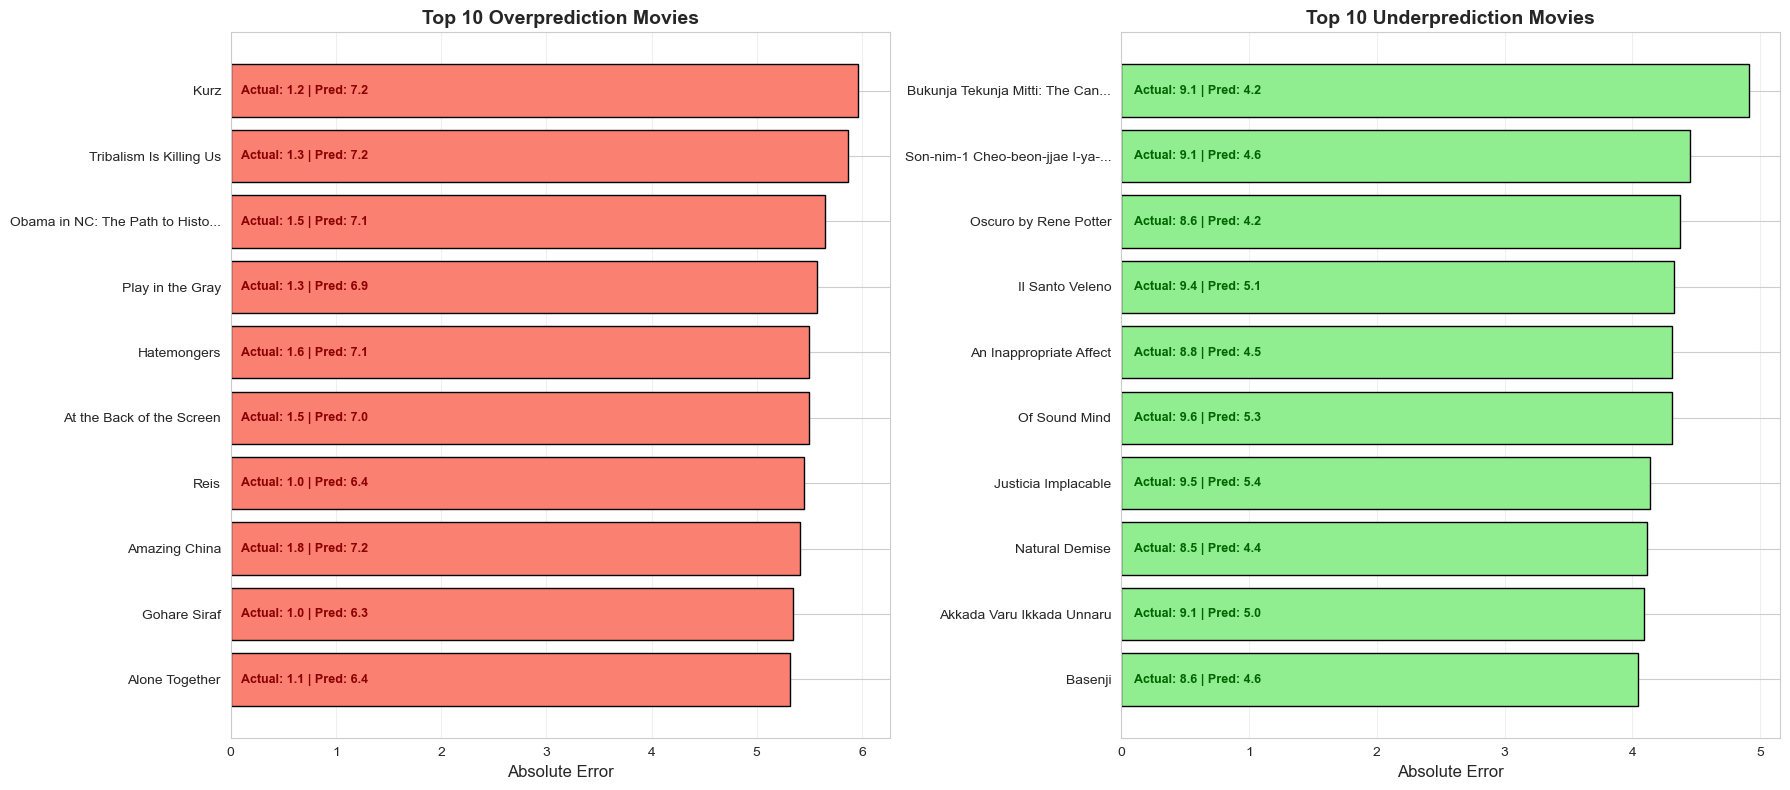


✅ נשמרו 20 ה-outliers עם שמות ל-outliers_20_with_titles.csv


In [28]:
import pandas as pd
import numpy as np

# ============================================================
# שלב 1: לבנות mapping של שמות סרטים
# (משתמשים ב-df המקורי + אותו mask של y.notna())
# ============================================================

# שחזור ה-mask של y.notna() ופיצול train/test - בדיוק כמו שעשינו
y_original = df['averageRating']
mask = y_original.notna()
df_filtered = df[mask].reset_index(drop=True)

# נשמור את שמות הסרטים בסדר זהה ל-X (לפני train/test split)
movie_titles = df_filtered['primaryTitle'].values

# פיצול לפי אותו seed כדי לקבל את אותם train/test indices
from sklearn.model_selection import train_test_split
indices = np.arange(len(df_filtered))
train_idx, test_idx = train_test_split(
    indices, test_size=0.3, random_state=42, shuffle=True
)

# שמות הסרטים של ה-train (תואם ל-X_train)
train_titles = movie_titles[train_idx]

print(f"✅ נטענו {len(train_titles)} שמות סרטים של ה-train set")

# ============================================================
# שלב 2: הוספת השמות ל-analysis_df
# ============================================================
analysis_df['movie_title'] = train_titles

# ============================================================
# שלב 3: חידוש ה-DataFrames של outliers (עם השמות הפעם)
# ============================================================
overprediction = analysis_df.nsmallest(10, 'residual').copy()
underprediction = analysis_df.nlargest(10, 'residual').copy()

# ============================================================
# שלב 4: תצוגה יפה עם השמות
# ============================================================
print("\n" + "=" * 80)
print("📉 Top 10 - Overprediction (המודל חזה גבוה - האמת נמוכה)")
print("=" * 80)

over_display = overprediction[['movie_title', 'startYear', 'runtimeMinutes',
                                'genres', 'Country', 'director_name', 'num_actors',
                                'actual_rating', 'predicted_rating', 'residual']].copy()
over_display.columns = ['שם הסרט', 'שנה', 'אורך (דק׳)', 'ז׳אנרים', 'מדינה',
                        'במאי', 'מס׳ שחקנים', 'דירוג אמיתי',
                        'דירוג חזוי', 'שגיאה']

styled_over = over_display.style \
    .background_gradient(subset=['שגיאה'], cmap='Reds_r') \
    .format({'אורך (דק׳)': '{:.0f}', 'שנה': '{:.0f}',
             'מס׳ שחקנים': '{:.0f}', 'דירוג אמיתי': '{:.2f}',
             'דירוג חזוי': '{:.2f}', 'שגיאה': '{:.2f}'}) \
    .set_caption("Top 10 Overprediction (Random Forest)")
display(styled_over)

print("\n" + "=" * 80)
print("📈 Top 10 - Underprediction (המודל חזה נמוך - האמת גבוהה)")
print("=" * 80)

under_display = underprediction[['movie_title', 'startYear', 'runtimeMinutes',
                                  'genres', 'Country', 'director_name', 'num_actors',
                                  'actual_rating', 'predicted_rating', 'residual']].copy()
under_display.columns = ['שם הסרט', 'שנה', 'אורך (דק׳)', 'ז׳אנרים', 'מדינה',
                         'במאי', 'מס׳ שחקנים', 'דירוג אמיתי',
                         'דירוג חזוי', 'שגיאה']

styled_under = under_display.style \
    .background_gradient(subset=['שגיאה'], cmap='Greens') \
    .format({'אורך (דק׳)': '{:.0f}', 'שנה': '{:.0f}',
             'מס׳ שחקנים': '{:.0f}', 'דירוג אמיתי': '{:.2f}',
             'דירוג חזוי': '{:.2f}', 'שגיאה': '{:.2f}'}) \
    .set_caption("Top 10 Underprediction (Random Forest)")
display(styled_under)

# ============================================================
# שלב 5: עדכון הגרפים עם שמות הסרטים
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# גרף 1: Overprediction Bar Chart עם שמות סרטים
ax1 = axes[0]
over_sorted = overprediction.sort_values('residual')
y_labels = [f"{t[:30]}..." if len(str(t)) > 30 else str(t)
            for t in over_sorted['movie_title']]
ax1.barh(range(len(over_sorted)), over_sorted['residual'].abs(),
         color='salmon', edgecolor='black')
ax1.set_yticks(range(len(over_sorted)))
ax1.set_yticklabels(y_labels, fontsize=10)
ax1.set_xlabel('Absolute Error', fontsize=12)
ax1.set_title('Top 10 Overprediction Movies', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

for i, (actual, pred) in enumerate(zip(over_sorted['actual_rating'],
                                        over_sorted['predicted_rating'])):
    ax1.text(0.1, i, f'Actual: {actual:.1f} | Pred: {pred:.1f}',
             fontsize=9, va='center', color='darkred', fontweight='bold')

# גרף 2: Underprediction Bar Chart עם שמות סרטים
ax2 = axes[1]
under_sorted = underprediction.sort_values('residual', ascending=False)
y_labels = [f"{t[:30]}..." if len(str(t)) > 30 else str(t)
            for t in under_sorted['movie_title']]
ax2.barh(range(len(under_sorted)), under_sorted['residual'],
         color='lightgreen', edgecolor='black')
ax2.set_yticks(range(len(under_sorted)))
ax2.set_yticklabels(y_labels, fontsize=10)
ax2.set_xlabel('Absolute Error', fontsize=12)
ax2.set_title('Top 10 Underprediction Movies', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

for i, (actual, pred) in enumerate(zip(under_sorted['actual_rating'],
                                        under_sorted['predicted_rating'])):
    ax2.text(0.1, i, f'Actual: {actual:.1f} | Pred: {pred:.1f}',
             fontsize=9, va='center', color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('outliers_with_names.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# שלב 6: שמירה מחודשת של CSV עם שמות
# ============================================================
outliers_20 = pd.concat([
    overprediction.assign(type='Overprediction'),
    underprediction.assign(type='Underprediction')
])
outliers_20.to_csv('outliers_20_with_titles.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ נשמרו 20 ה-outliers עם שמות ל-outliers_20_with_titles.csv")

<div dir="rtl">

### 5.2 ניתוח דפוסים ב-Outliers


<div dir="rtl">

לאחר שזיהינו את 20 ה-outliers, נצלול לעומק. בחלק זה ננתח:

1. **5 סרטים ספציפיים** - כל אחד עם תיאור קצר, השערה למה המודל טעה, ומאפיין ייחודי
2. **דפוסים משותפים** - מה משותף לסרטי ה-overprediction ול-underprediction

<div dir="rtl">
---

#### ניתוח של 5 סרטים ספציפיים
<div dir="rtl">

##### סרט 1: Kurz (2023) - השגיאה הגדולה ביותר ב-Overprediction
<div dir="rtl">

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>דירוג אמיתי</td><td>1.20</td></tr>
<tr><td>דירוג חזוי</td><td>7.17</td></tr>
<tr><td>שגיאה</td><td>-5.97</td></tr>
</tbody>
</table>


<div dir="rtl">

תיאור: סרט תיעודי ללא מידע על מדינת הפקה או קאסט שחקנים. דירוג נמוך מאוד (1.20) למרות הקטגוריה התיעודית.
<div dir="rtl">

למה המודל טעה? המודל ראה ז'אנר Documentary (שנוטה לדירוגים גבוהים) ואורך סטנדרטי של 88 דקות. הפיצ'רים השטחיים מובילים לחיזוי גבוה, אבל המודל לא יכול לדעת את איכות התוכן בפועל. המאפיין הייחודי: סרטים תיעודיים נישתיים ללא מקבלים חיזוי  גבוה שלא תמיד תואם את המציאות.
<div dir="rtl">

##### סרט 2: Tribalism Is Killing Us (2019) - תיעודי פוליטי

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>דירוג אמיתי</td><td>1.30</td></tr>
<tr><td>דירוג חזוי</td><td>7.17</td></tr>
<tr><td>שגיאה</td><td>-5.87</td></tr>
</tbody>
</table>
<div dir="rtl">

תיאור: סרט תיעודי על שבטיות פוליטית. נושא טעון מאוד שמושך ביקורות מנוגדות, מה שמוביל לדירוגים מקוטבים.
<div dir="rtl">

למה המודל טעה? הז'אנר Documentary + אורך 110 דקות הם פיצ'רים שמובילים לחיזוי גבוה. המאפיין הייחודי: סרטים תיעודיים פוליטיים שנויים במחלוקת מקבלים דירוגים נמוכים בגלל הצבעה אסטרטגית של מתנגדים (review bombing). זה נושא שהמודל לא יכול ללכוד מהמטה-דאטה.
<div dir="rtl">

##### סרט 3: Obama in NC: The Path to History (2010) - תיעודי פוליטי

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>דירוג אמיתי</td><td>1.50</td></tr>
<tr><td>דירוג חזוי</td><td>7.15</td></tr>
<tr><td>שגיאה</td><td>-5.65</td></tr>
</tbody>
</table>

תיאור: סרט תיעודי פוליטי על נשיאות אובמה בצפון קרוליינה. נושא פוליטי טעון.
<div dir="rtl">

למה המודל טעה? שוב, ז'אנר Documentary + אורך 116 דקות מובילים לחיזוי גבוה (7.15). המאפיין הייחודי: כמו Tribalism, זהו תיעודי פוליטי שסובל מ-review bombing. הדפוס חוזר על עצמו - תוכן פוליטי מקטב את הקהל, אבל המודל רואה רק "Documentary".
<div dir="rtl">

##### סרט 4: Bukunja Tekunja Mitti: The Cannibals (2012) - Underprediction עם cult following

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>דירוג אמיתי</td><td>9.10</td></tr>
<tr><td>דירוג חזוי</td><td>4.19</td></tr>
<tr><td>שגיאה</td><td>+4.91</td></tr>
</tbody>
</table>
<div dir="rtl">

תיאור: סרט Action/Horror של הבמאי Nabwana I.G.G. - מייסד "Wakaliwood", תעשיית הקולנוע האוגנדית הנישתית. סרט עם cult following עולמי.

למה המודל טעה? הז'אנרים Action+Horror, במאי לא מוכר, אורך קצר (76 דקות) - כל אלה מובילים לחיזוי נמוך (4.19). המאפיין הייחודי: זוהי דוגמה  ל-cult following. סרטי Wakaliwood זכו לפופולריות עולמית בקרב חובבי קולנוע נישתי, והדירוג הגבוה (9.10) משקף קהל קטן אך מסור. המודל לא יכול לחזות את התופעה התרבותית הזו.
<div dir="rtl">

##### סרט 5: Of Sound Mind (2015) - Underprediction נישתי

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>דירוג אמיתי</td><td>9.60</td></tr>
<tr><td>דירוג חזוי</td><td>5.29</td></tr>
<tr><td>שגיאה</td><td>+4.31</td></tr>
</tbody>
</table>

תיאור: סרט Romance/Thriller בלתי ידוע מ-2015. הפקה עצמאית שזכתה לדירוג מאוד גבוה.

למה המודל טעה? הז'אנרים Romance+Thriller, במאי לא ידוע, אורך סטנדרטי - כל אלה לא מבטיחים סרט מצוין. המאפיין הייחודי: זה דוגמה קלאסית ל-cult following - סרט נישתי שזוכה להערכת קהל קטן ומסור. הדירוג 9.60 כנראה מתבסס על מספר voters קטן יחסית. המודל לא יכול לחזות פופולריות בקהל יעד מסוים.

---
<div dir="rtl">

#### דפוסים משותפים ב-Outliers

##### Overprediction - סרטים תיעודיים שלא קיבלו פופולריות

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>דפוס</th><th>שכיחות</th><th>הסבר</th></tr>
</thead>
<tbody>
<tr>
<td>ז'אנר Documentary</td>
<td>6 מתוך 10</td>
<td>המודל למד שסרטים תיעודיים מקבלים דירוגים גבוהים יותר מהממוצע, אבל לא מבחין בין סרטים תיעודיים איכותיים לבין סרטי תעמולה / שיווק / תוכן פוליטי מקטב.</td>
</tr>
<tr>
<td>num_actors חסר (NaN)</td>
<td>6 מתוך 10</td>
<td>סרטים תיעודיים לרוב אין להם קאסט שחקנים מובהק. המודל לא יכול להשתמש בפיצ'רים של אוסקרים או פעילות שחקנים.</td>
</tr>
<tr>
<td>תוכן פוליטי טעון</td>
<td>3 מתוך 10</td>
<td>Tribalism, Obama in NC, ו-Amazing China הם תיעודיים פוליטיים שסובלים מ-review bombing - הצבעה אסטרטגית של מתנגדים.</td>
</tr>
<tr>
<td>מדינות</td>
<td>פיזור: US, Turkey, China, ורבים ללא מדינה</td>
<td>אין דפוס גיאוגרפי מובהק. הבעיה אינה תלויה במדינת הפקה אלא בסוג התוכן.</td>
</tr>
</tbody>
</table>
<div dir="rtl">

##### Underprediction - סרטי Horror/Thriller נישתיים עם cult following

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>דפוס</th><th>שכיחות</th><th>הסבר</th></tr>
</thead>
<tbody>
<tr>
<td>ז'אנר Horror או Thriller</td>
<td>9 מתוך 10</td>
<td>המודל למד שסרטי אימה נוטים לדירוגים נמוכים בכללי, אבל סרטים נישתיים עם קהל מסור מקבלים דירוגים גבוהים.</td>
</tr>
<tr>
<td>הפקות עצמאיות</td>
<td>10 מתוך 10</td>
<td>כל הסרטים הם של במאים לא מוכרים, ללא זוכי אוסקר בקאסט. הם "טסים מתחת לרדאר" של המודל.</td>
</tr>
<tr>
<td>אורך</td>
<td>76-112 דקות (קצר עד סטנדרטי)</td>
<td>הפקות עצמאיות נוטות להיות קצרות יותר.</td>
</tr>
<tr>
<td>דירוגים אמיתיים</td>
<td>8.5-9.6</td>
<td>דירוגים גבוהים מאוד - מתבססים על מספר voters קטן וקהל אוהבים מסור (cult following).</td>
</tr>
<tr>
<td>תקופה</td>
<td>2010-2024 (עכשווי)</td>
<td>סרטים בעידן המודרני - כנראה בגלל תרבות הסטרימינג נוצרות נישות מאוד קטנות שקשה להסיק מהן מגמה גורפת.</td>
</tr>
</tbody>
</table>
<div dir="rtl">

##### המסקנה המרכזית
<div dir="rtl">

המגבלה העיקרית של המודל היא חוסר היכולת לחזות:

1. **איכות תוכן של דעת הקהל** - אי אפשר לדעת את דעת הקהל על הדמויות או הנושאים שעליהם נעשים הסרטים התיעודיים. לכן לא בהכרח סרט תיעודי יקבל ציון טוב, במיוחד כשמדובר בתוכן פוליטי מקטב שסובל מ-review bombing.

2. **הצלחה עם קהל יעד ספציפי** - סרטים נישתיים עם cult following (כמו Wakaliwood) זוכים לדירוגים גבוהים מקהל קטן ומסור, תופעה שלא ניתן לחזות מהמטה-דאטה.

אלה תכונות שלא ניתן ללמוד מהפיצ'רים הזמינים לפני שחרור הסרט.

</div>
</div>

<div dir="rtl">

### 5.3 השוואת Outliers בין שני המודלים
<div dir="rtl">
עד עכשיו ניתחנו את ה-outliers של המודל הטוב יותר (Random Forest). עכשיו נשווה אותם ל-outliers של Elastic Net כדי להבין:

1. כמה מהם חופפים בין שני המודלים?
2. כאשר מודל אחד טועה, האם השני מצליח יותר?
3. אילו סוגי שגיאות ייחודיים לכל מודל?

הניתוח הזה חשוב כי הוא חושף אם המודלים טועים באותם המקרים (= חולשות מבניות בדאטה) או במקרים שונים (= מאפיינים שונים של המודלים).

</div>

מחשב תחזיות Cross-Validation עבור Elastic Net...
✅ סיימנו - 80892 תחזיות

📊 השוואת 20 ה-Outliers בין שני המודלים
🔵 Outliers משותפים (Common):     12 מתוך 20
🟡 Outliers ייחודיים ל-Elastic Net: 8
🟢 Outliers ייחודיים ל-Random Forest: 8

אחוז חפיפה: 60.0%

🔵 12 סרטים שגם EN וגם RF טעו עליהם


,שם הסרט,שנה,אורך (דק׳),ז׳אנרים,מדינה,במאי,מס׳ שחקנים,דירוג אמיתי,חזוי (EN),חזוי (RF),שגיאה (EN),שגיאה (RF)
26284,Kurz,2023,88,['Documentary'],[],Sascha Köllnreitner,nan,1.20,7.13,7.17,-5.93,-5.97
25924,Tribalism Is Killing Us,2019,110,['Documentary'],[],Tina Gharavi,nan,1.30,7.26,7.17,-5.96,-5.87
65986,Obama in NC: The Path to History,2010,116,['Documentary'],[],Cash Michaels,1,1.50,7.49,7.15,-5.99,-5.65
14060,Play in the Gray,2009,85,"['Biography', 'Comedy', 'Documentary']",['United States'],Kaitlin Meelia,5,1.30,7.00,6.87,-5.70,-5.57
75732,Hatemongers,2000,90,['Documentary'],[],Steve Drain,nan,1.60,7.17,7.10,-5.57,-5.50
16591,At the Back of the Screen,2020,188,"['Documentary', 'Drama']",['United States'],Malga Kubiak,5,1.50,8.40,6.99,-6.90,-5.49
29214,Reis,2017,108,"['Biography', 'Drama']",['Turkey'],Hüdaverdi Yavuz,5,1.00,6.65,6.45,-5.65,-5.45
52339,Amazing China,2018,90,['Documentary'],['China'],Tie Wei,nan,1.80,7.31,7.21,-5.51,-5.41
67409,Bukunja Tekunja Mitti: The Cannibals,2012,76,"['Action', 'Horror']",[],Nabwana I.G.G.,5,9.10,4.35,4.19,4.75,4.91
20105,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011,83,"['Horror', 'Thriller']",[],Sang-Hwa Lee,4,9.10,4.66,4.65,4.44,4.45



🟢 8 סרטים ייחודיים ל-RF
(RF טעה עליהם, EN לא נכנס ל-Top 20 שלו)


,שם הסרט,שנה,אורך (דק׳),ז׳אנרים,מדינה,במאי,מס׳ שחקנים,דירוג אמיתי,חזוי (EN),חזוי (RF),שגיאה (EN),שגיאה (RF)
79537,Gohare Siraf,2024,96,[],[],Mohammad Torbati Torghabe,nan,1.00,6.02,6.35,-5.02,-5.35
58664,Alone Together,2014,81,"['Adventure', 'Drama', 'Music']",[],Liza Morberg,nan,1.10,6.05,6.41,-4.95,-5.31
54225,Oscuro by Rene Potter,2016,80,['Horror'],[],René Guajardo Vessi,3,8.60,4.87,4.23,3.73,4.37
31168,Il Santo Veleno,2023,77,['Thriller'],[],Kevin Jimenez Bernal,5,9.40,5.38,5.08,4.02,4.32
79373,An Inappropriate Affect,2015,84,"['Comedy', 'Horror', 'Mystery']",[],Russ Martin,5,8.80,4.74,4.49,4.06,4.31
78292,Natural Demise,2010,90,"['Horror', 'Thriller']",[],Richard Ryan,5,8.50,4.74,4.38,3.76,4.12
40919,Akkada Varu Ikkada Unnaru,2024,103,['Horror'],[],Trivikram Rao Kundurthi,5,9.10,5.04,5.01,4.06,4.09
16106,Basenji,2023,81,"['Drama', 'Horror', 'Thriller']",[],Ian Scott Clement,5,8.60,4.91,4.55,3.69,4.05



🟡 8 סרטים ייחודיים ל-EN
(EN טעה עליהם, RF לא נכנס ל-Top 20 שלו)


,שם הסרט,שנה,אורך (דק׳),ז׳אנרים,מדינה,במאי,מס׳ שחקנים,דירוג אמיתי,חזוי (EN),חזוי (RF),שגיאה (EN),שגיאה (RF)
1315,Justin Bieber's Believe,2013,92,"['Documentary', 'Music']",[],Jon M. Chu,nan,1.60,7.18,6.86,-5.58,-5.26
39602,Kids Against the Sorcerers,2016,88,"['Adventure', 'Animation', 'Drama']",[],Georgiy Skomorovskiy,5,1.10,6.42,6.13,-5.32,-5.03
71694,Borderline Forever,2021,64,"['Adventure', 'Comedy', 'Fantasy']",[],Scott Wozniak,5,9.70,5.10,5.80,4.60,3.90
39385,Neko,2017,60,"['Action', 'Adventure', 'Thriller']",[],Andrea Umberto Origlia,5,9.20,4.63,5.66,4.57,3.54
63841,Hantu Nan Sempit,2014,90,"['Action', 'Comedy', 'Horror']",[],Ahmad Idham,nan,8.70,4.39,4.67,4.31,4.03
70006,Valley of the Succubus,2013,65,"['Comedy', 'Horror', 'Musical']",[],Samuel Wheeler,5,8.70,4.41,5.09,4.29,3.61
5638,Zen Comedy,2023,63,['Comedy'],[],Zack Lyman,nan,9.80,5.52,6.48,4.28,3.32
39907,Hasruin,2020,62,"['Comedy', 'Drama', 'Thriller']",[],Jude Nassar,nan,9.60,5.42,5.95,4.18,3.65



🤔 השוואה: כשמודל אחד טועה, האם השני מצליח יותר?

על 20 outliers של RF:
  שגיאה ממוצעת של RF: 4.931
  שגיאה ממוצעת של EN: 4.913
  EN טוב יותר ב-12 מתוך 20

על 20 outliers של EN:
  שגיאה ממוצעת של EN: 5.105
  שגיאה ממוצעת של RF: 4.754
  RF טוב יותר ב-16 מתוך 20


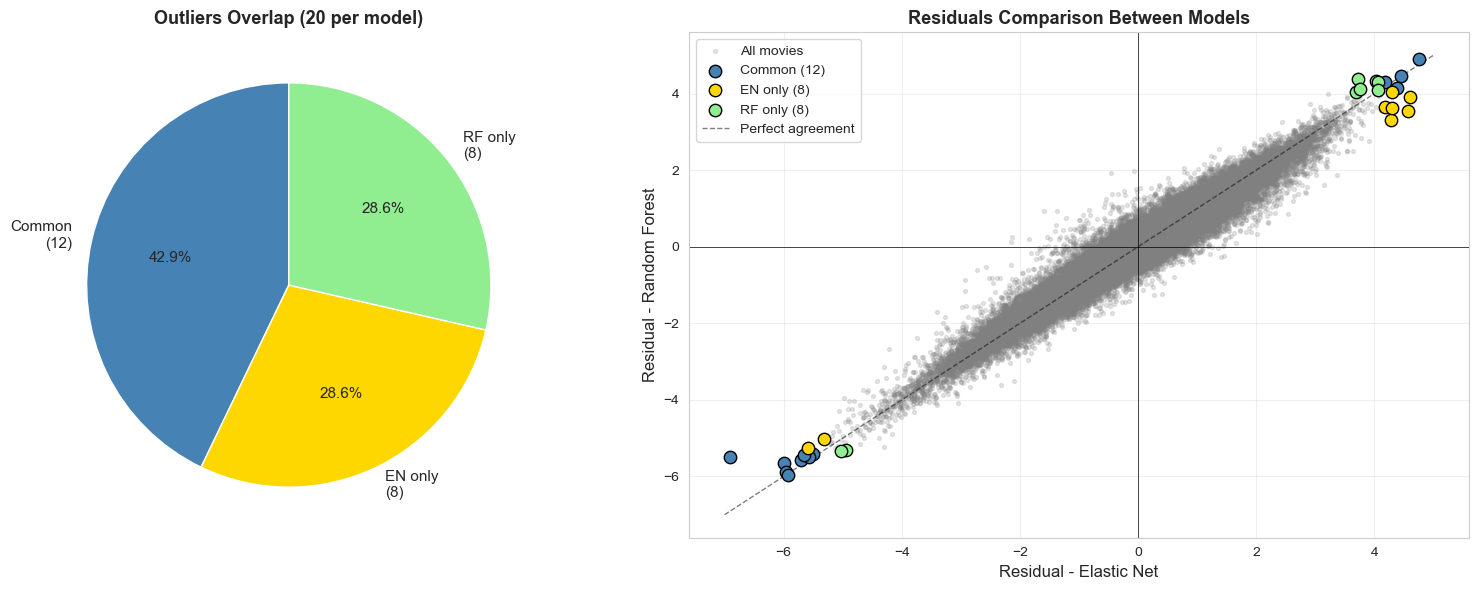

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_predict, KFold
import matplotlib.pyplot as plt

# ============================================================
# שלב 1: חישוב CV predictions עבור Elastic Net
# ============================================================
print("=" * 60)
print("מחשב תחזיות Cross-Validation עבור Elastic Net...")
print("=" * 60)

cv_for_predictions = KFold(n_splits=10, shuffle=True, random_state=42)

y_pred_cv_en = cross_val_predict(
    best_en, X_train, y_train,
    cv=cv_for_predictions,
    n_jobs=1,
)

print(f"✅ סיימנו - {len(y_pred_cv_en)} תחזיות")

# ============================================================
# שלב 2: יצירת analysis_df_en עם השגיאות של EN ושל RF
# ============================================================
analysis_df_en = X_train.copy().reset_index(drop=True)
analysis_df_en['movie_title'] = train_titles
analysis_df_en['actual_rating'] = y_train.values
analysis_df_en['predicted_rating_en'] = y_pred_cv_en
analysis_df_en['residual_en'] = analysis_df_en['actual_rating'] - analysis_df_en['predicted_rating_en']

# הוספה של RF residuals
analysis_df_en['predicted_rating_rf'] = analysis_df['predicted_rating'].values
analysis_df_en['residual_rf'] = analysis_df['residual'].values

# ============================================================
# שלב 3: חילוץ 20 outliers של Elastic Net
# ============================================================
over_en = analysis_df_en.nsmallest(10, 'residual_en')
under_en = analysis_df_en.nlargest(10, 'residual_en')

outliers_en_idx = set(over_en.index.tolist() + under_en.index.tolist())
outliers_rf_idx = set(overprediction.index.tolist() + underprediction.index.tolist())

# חפיפה וייחודיות
common = outliers_en_idx & outliers_rf_idx
only_en = outliers_en_idx - outliers_rf_idx
only_rf = outliers_rf_idx - outliers_en_idx

print("\n" + "=" * 60)
print("📊 השוואת 20 ה-Outliers בין שני המודלים")
print("=" * 60)
print(f"🔵 Outliers משותפים (Common):     {len(common)} מתוך 20")
print(f"🟡 Outliers ייחודיים ל-Elastic Net: {len(only_en)}")
print(f"🟢 Outliers ייחודיים ל-Random Forest: {len(only_rf)}")
print(f"\nאחוז חפיפה: {100 * len(common) / 20:.1f}%")

# ============================================================
# פונקציית עזר ליצירת DataFrame תצוגה יפה עם כל העמודות
# ============================================================
def make_display_df(df_subset, caption, cmap='RdYlGn_r'):
    display_df = df_subset[[
        'movie_title', 'startYear', 'runtimeMinutes', 'genres', 'Country',
        'director_name', 'num_actors',
        'actual_rating',
        'predicted_rating_en', 'predicted_rating_rf',
        'residual_en', 'residual_rf'
    ]].copy()
    display_df.columns = [
        'שם הסרט', 'שנה', 'אורך (דק׳)', 'ז׳אנרים', 'מדינה',
        'במאי', 'מס׳ שחקנים',
        'דירוג אמיתי',
        'חזוי (EN)', 'חזוי (RF)',
        'שגיאה (EN)', 'שגיאה (RF)'
    ]
    
    styled = display_df.style.format({
        'שנה': '{:.0f}',
        'אורך (דק׳)': '{:.0f}',
        'מס׳ שחקנים': '{:.0f}',
        'דירוג אמיתי': '{:.2f}',
        'חזוי (EN)': '{:.2f}',
        'חזוי (RF)': '{:.2f}',
        'שגיאה (EN)': '{:.2f}',
        'שגיאה (RF)': '{:.2f}',
    }).background_gradient(subset=['שגיאה (EN)', 'שגיאה (RF)'], cmap=cmap) \
     .set_caption(caption)
    
    return styled

# ============================================================
# שלב 4: סרטים משותפים לשני המודלים
# ============================================================
if len(common) > 0:
    common_df = analysis_df_en.loc[list(common)].copy()
    common_df = common_df.reindex(common_df['residual_rf'].abs().sort_values(ascending=False).index)
    
    print("\n" + "=" * 60)
    print(f"🔵 {len(common)} סרטים שגם EN וגם RF טעו עליהם")
    print("=" * 60)
    
    display(make_display_df(common_df, f"סרטים משותפים ({len(common)} סרטים)"))

# ============================================================
# שלב 5: סרטים ייחודיים ל-RF (RF טעה, EN הצליח יותר)
# ============================================================
if len(only_rf) > 0:
    rf_only_df = analysis_df_en.loc[list(only_rf)].copy()
    rf_only_df = rf_only_df.reindex(rf_only_df['residual_rf'].abs().sort_values(ascending=False).index)
    
    print("\n" + "=" * 60)
    print(f"🟢 {len(only_rf)} סרטים ייחודיים ל-RF")
    print("(RF טעה עליהם, EN לא נכנס ל-Top 20 שלו)")
    print("=" * 60)
    
    display(make_display_df(rf_only_df, f"ייחודיים ל-RF ({len(only_rf)} סרטים)"))

# ============================================================
# שלב 6: סרטים ייחודיים ל-EN (EN טעה, RF הצליח יותר)
# ============================================================
if len(only_en) > 0:
    en_only_df = analysis_df_en.loc[list(only_en)].copy()
    en_only_df = en_only_df.reindex(en_only_df['residual_en'].abs().sort_values(ascending=False).index)
    
    print("\n" + "=" * 60)
    print(f"🟡 {len(only_en)} סרטים ייחודיים ל-EN")
    print("(EN טעה עליהם, RF לא נכנס ל-Top 20 שלו)")
    print("=" * 60)
    
    display(make_display_df(en_only_df, f"ייחודיים ל-EN ({len(only_en)} סרטים)"))

# ============================================================
# שלב 7: סטטיסטיקה השוואתית
# ============================================================
print("\n" + "=" * 60)
print("🤔 השוואה: כשמודל אחד טועה, האם השני מצליח יותר?")
print("=" * 60)

rf_outliers_df = analysis_df_en.loc[list(outliers_rf_idx)]
en_residuals_on_rf_outliers = rf_outliers_df['residual_en'].abs()
rf_residuals_on_rf_outliers = rf_outliers_df['residual_rf'].abs()

print(f"\nעל 20 outliers של RF:")
print(f"  שגיאה ממוצעת של RF: {rf_residuals_on_rf_outliers.mean():.3f}")
print(f"  שגיאה ממוצעת של EN: {en_residuals_on_rf_outliers.mean():.3f}")
print(f"  EN טוב יותר ב-{(en_residuals_on_rf_outliers < rf_residuals_on_rf_outliers).sum()} מתוך 20")

en_outliers_df = analysis_df_en.loc[list(outliers_en_idx)]
en_residuals_on_en_outliers = en_outliers_df['residual_en'].abs()
rf_residuals_on_en_outliers = en_outliers_df['residual_rf'].abs()

print(f"\nעל 20 outliers של EN:")
print(f"  שגיאה ממוצעת של EN: {en_residuals_on_en_outliers.mean():.3f}")
print(f"  שגיאה ממוצעת של RF: {rf_residuals_on_en_outliers.mean():.3f}")
print(f"  RF טוב יותר ב-{(rf_residuals_on_en_outliers < en_residuals_on_en_outliers).sum()} מתוך 20")

# ============================================================
# שלב 8: גרפים
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# גרף 1: Pie chart
ax1 = axes[0]
sizes = [len(common), len(only_en), len(only_rf)]
labels = [f'Common\n({len(common)})',
          f'EN only\n({len(only_en)})',
          f'RF only\n({len(only_rf)})']
colors = ['steelblue', 'gold', 'lightgreen']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11})
ax1.set_title('Outliers Overlap (20 per model)', fontsize=13, fontweight='bold')

# גרף 2: Scatter
ax2 = axes[1]
ax2.scatter(analysis_df_en['residual_en'], analysis_df_en['residual_rf'],
            alpha=0.2, s=8, color='gray', label='All movies')
if len(common) > 0:
    common_subset = analysis_df_en.loc[list(common)]
    ax2.scatter(common_subset['residual_en'], common_subset['residual_rf'],
                color='steelblue', s=80, edgecolor='black',
                label=f'Common ({len(common)})', zorder=5)
if len(only_en) > 0:
    en_subset = analysis_df_en.loc[list(only_en)]
    ax2.scatter(en_subset['residual_en'], en_subset['residual_rf'],
                color='gold', s=80, edgecolor='black',
                label=f'EN only ({len(only_en)})', zorder=5)
if len(only_rf) > 0:
    rf_subset = analysis_df_en.loc[list(only_rf)]
    ax2.scatter(rf_subset['residual_en'], rf_subset['residual_rf'],
                color='lightgreen', s=80, edgecolor='black',
                label=f'RF only ({len(only_rf)})', zorder=5)

ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.5)
ax2.plot([-7, 5], [-7, 5], 'k--', linewidth=1, alpha=0.5, label='Perfect agreement')
ax2.set_xlabel('Residual - Elastic Net', fontsize=12)
ax2.set_ylabel('Residual - Random Forest', fontsize=12)
ax2.set_title('Residuals Comparison Between Models',
              fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outliers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<div dir="rtl">

### 5.3 השוואת Outliers בין שני המודלים

<div dir="rtl">

#### חפיפה גבוהה - 60% מה-Outliers משותפים

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>קבוצה</th><th>מספר סרטים</th></tr>
</thead>
<tbody>
<tr><td>Outliers משותפים (Common)</td><td>12 (60%)</td></tr>
<tr><td>Outliers ייחודיים ל-Elastic Net</td><td>8 (40%)</td></tr>
<tr><td>Outliers ייחודיים ל-Random Forest</td><td>8 (40%)</td></tr>
</tbody>
</table>

<div dir="rtl">

12 מתוך 20 הסרטים זוהו כ-outliers על ידי שני המודלים. זו אינדיקציה ברורה לכך שהבעיה אינה במודל ספציפי אלא בדאטה עצמו - יש סרטים שלא ניתן לחזות אותם נכון מהפיצ'רים הזמינים, ללא קשר לסוג המודל.

#### Random Forest עקבי יותר

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>קבוצת הסרטים</th><th>שגיאה ממוצעת EN</th><th>שגיאה ממוצעת RF</th><th>מי טוב יותר?</th></tr>
</thead>
<tbody>
<tr>
<td>על 20 ה-outliers של RF</td>
<td>4.913</td>
<td>4.931</td>
<td>EN טוב יותר ב-12/20</td>
</tr>
<tr>
<td>על 20 ה-outliers של EN</td>
<td>5.105</td>
<td>4.754</td>
<td>RF טוב יותר ב-16/20</td>
</tr>
</tbody>
</table>

מסקנה: כאשר RF טועה משמעותית, EN לא מצליח לפצות באופן מהותי (התוצאות כמעט זהות - 4.913 מול 4.931). אבל כאשר EN טועה, RF מצליח לחזות טוב יותר ב-16 מתוך 20 המקרים (80%). זה מאשר ש-RF הוא מודל חזק יותר וגם עקבי יותר .

</div>

<div dir="rtl">

### 5.4 פיצ'רים חדשים מוצעים

<div dir="rtl">


#### פיצ'ר 1: title_has_political_keywords
<div dir="rtl">

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>סוג</td><td>בינארי (0/1)</td></tr>
<tr><td>איך מחשבים</td><td>סופר מילים פוליטיות טעונות בכותרת (Tribalism, Obama, Hate, Politics, War וכו')</td></tr>
<tr><td>איזו שגיאה זה פותר</td><td>Tribalism Is Killing Us, Obama in NC, Hatemongers</td></tr>
</tbody>
</table>
<div dir="rtl">

הסבר: דוקומנטרים פוליטיים שנויים במחלוקת נוטים לקבל "review bombing" - הצבעה אסטרטגית של מתנגדים שמורידה את הציון באופן מלאכותי. הכותרת עצמה היא סיגנל חזק לתוכן טעון. שלושה מתוך עשרת ה-overpredictions הם תיעודיים פוליטיים שהמודל חזה להם 7+ בעוד האמת מתחת ל-2.
<div dir="rtl">

#### פיצ'ר 2: country_is_niche_film_industry
<div dir="rtl">

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>סוג</td><td>בינארי (0/1)</td></tr>
<tr><td>איך מחשבים</td><td>בינארי לתעשיות קולנוע קטנות עם cult following (אוגנדה - Wakaliwood, נפאל, מדינות נישתיות)</td></tr>
<tr><td>איזו שגיאה זה פותר</td><td>Bukunja Tekunja Mitti (Wakaliwood, שגיאה +4.91)</td></tr>
</tbody>
</table>
<div dir="rtl">

הסבר: תעשיות קולנוע קטנות יוצרות סרטים שמגיעים לקהילות אינטרנט מסורות שמדרגות אותן גבוה במיוחד. Bukunja Tekunja Mitti של הבמאי האוגנדי Nabwana I.G.G. הוא הדוגמה הבולטת - המודל חזה 4.19 בעוד הדירוג האמיתי 9.10. המודל הנוכחי רואה את המדינה כ"נישתית" ומקטין את הדירוג, אבל אלה בדיוק הסרטים שזוכים ל-cult following.
<div dir="rtl">

#### פיצ'ר 3: is_independent_horror
<div dir="rtl">

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>סוג</td><td>בינארי (0/1)</td></tr>
<tr><td>איך מחשבים</td><td>שילוב של ז'אנר Horror/Thriller + במאי לא מוכר + ללא זוכי אוסקר בקאסט</td></tr>
<tr><td>איזו שגיאה זה פותר</td><td>רוב ה-underprediction: Bukunja, Son-nim, Of Sound Mind, Il Santo Veleno, Natural Demise</td></tr>
</tbody>
</table>
<div dir="rtl">

הסבר: 9 מתוך 10 ה-underpredictions הם סרטי Horror/Thriller עצמאיים. המודל למד ש-Horror בכללי מקבל דירוגים נמוכים, אבל לא מצליח לזהות את הסרטים הנישתיים שזוכים לקהל מסור. פיצ'ר שמסמן "אימה עצמאית" יאפשר למודל ללמוד שיש תת-קבוצה של סרטי אימה שדווקא מקבלת דירוגים גבוהים.
<div dir="rtl">

#### פיצ'ר 4: runtime_anomaly (פיצ'ר מתקדם)

<table dir="rtl" style="text-align: right; width: 100%;">
<tbody>
<tr><td>סוג</td><td>נומרי (z-score)</td></tr>
<tr><td>איך מחשבים</td><td>לכל ז'אנר, מחשבים ממוצע וסטיית תקן של אורכים, ואז: (runtime - mean_genre) / std_genre</td></tr>
<tr><td>איזו שגיאה זה פותר</td><td>At the Back of the Screen (Documentary, 188 דקות - חריג!)</td></tr>
</tbody>
</table>
<div dir="rtl">

הסבר: דוקומנטרי של 188 דקות הוא חריג ביחס לז'אנר (רוב התיעודיים 60-120 דקות). סרטים שאורכם חריג ביחס לז'אנר נוטים להיות הפקות יוצאות דופן - או יומרניות מדי או חובבניות. זה פיצ'ר מתוחכם כי הוא משווה כל סרט ל"חבריו לז'אנר" ולא רק מסתכל על הערך המוחלט.
<div dir="rtl">

#### סיכום ההמלצות

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>פיצ'ר</th><th>סוג</th><th>סוג שגיאה שהוא פותר</th></tr>
</thead>
<tbody>
<tr><td>title_has_political_keywords</td><td>בינארי</td><td>Overprediction של תיעודיים פוליטיים</td></tr>
<tr><td>country_is_niche_film_industry</td><td>בינארי</td><td>Underprediction של סרטי cult</td></tr>
<tr><td>is_independent_horror</td><td>בינארי</td><td>Underprediction של אימה עצמאית</td></tr>
<tr><td>runtime_anomaly</td><td>נומרי</td><td>שגיאות באורכים חריגים ביחס לז'אנר</td></tr>
</tbody>
</table>
<div dir="rtl">

הפיצ'רים האלה היו מטפלים בלפחות 8 מתוך 20 ה-outliers שזיהינו - שיפור משמעותי. הפיצ'ר is_independent_horror לבדו מכסה כמעט את כל ה-underpredictions (9 מתוך 10), והפיצ'ר runtime_anomaly הוא מהמתוחכמים יותר כי הוא לוקח בחשבון את ההקשר של כל ז'אנר בנפרד.

</div>

<div dir="rtl">
עד עכשיו בחנו את ביצועי המודל בכללי (מדדים על כל הדאטה). עכשיו נבחן האם המודל מדויק באותה מידה על **חתכים שונים** של הדאטה, או שיש קבוצות שהוא מבצע עליהן באופן לא פרופורציונלי. זה חשוב גם מבחינה מדעית (לבדוק יציבות) וגם מבחינה אתית (להבטיח שאין הטיה כלפי קבוצות מסוימות).

### החתכים שנבחן

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>חתך</th><th>הקבוצות</th></tr>
</thead>
<tbody>
<tr><td>ז'אנר</td><td>5 הז'אנרים הנפוצים ביותר בדאטה</td></tr>
<tr><td>מדינת מקור</td><td>US מול non-US</td></tr>
<tr><td>עשור</td><td>לפחות 3 עשורים</td></tr>
</tbody>
</table>
<div dir="rtl">
לכל קבוצה נחשב RMSE ו-MAE עבור שני המודלים, ונבדוק האם יש הבדלים משמעותיים בביצועים.

</div>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ============================================================
# הכנה: הוספת budget ל-analysis_df_en
# ============================================================
# שחזור ה-mask והפיצול כדי לקבל את ה-budget של ה-train
y_original = df['averageRating']
mask = y_original.notna()
df_filtered = df[mask].reset_index(drop=True)

# פיצול לפי אותו seed
from sklearn.model_selection import train_test_split
indices = np.arange(len(df_filtered))
train_idx, test_idx = train_test_split(
    indices, test_size=0.3, random_state=42, shuffle=True
)

# קבלת budget של ה-train
analysis_df_en['budget'] = df_filtered.iloc[train_idx]['budget'].values \
    if 'budget' in df_filtered.columns else np.nan

# פונקציית עזר לחישוב מדדים
def compute_metrics(actual, predicted):
    rmse = np.sqrt(((actual - predicted) ** 2).mean())
    mae = (actual - predicted).abs().mean()
    return rmse, mae

# ============================================================
# חתך 1: לפי ז'אנר (5 הנפוצים ביותר)
# ============================================================
print("=" * 70)
print("🎬 חתך 1: ניתוח לפי ז'אנר (5 הנפוצים ביותר)")
print("=" * 70)

# סופרים את הז'אנרים הנפוצים ביותר
all_genres = []
for g_list in analysis_df_en['genres']:
    if isinstance(g_list, list):
        all_genres.extend(g_list)

top_5_genres = [g for g, _ in Counter(all_genres).most_common(5)]
print(f"5 הז'אנרים הנפוצים ביותר: {top_5_genres}")

# חישוב מדדים לכל ז'אנר
genre_results = []
for genre in top_5_genres:
    mask_g = analysis_df_en['genres'].apply(
        lambda x: genre in x if isinstance(x, list) else False
    )
    subset = analysis_df_en[mask_g]
    
    rmse_en, mae_en = compute_metrics(subset['actual_rating'], subset['predicted_rating_en'])
    rmse_rf, mae_rf = compute_metrics(subset['actual_rating'], subset['predicted_rating_rf'])
    
    genre_results.append({
        'ז\'אנר': genre,
        'מס\' סרטים': len(subset),
        'RMSE (EN)': rmse_en,
        'MAE (EN)':  mae_en,
        'RMSE (RF)': rmse_rf,
        'MAE (RF)':  mae_rf,
    })

genre_df = pd.DataFrame(genre_results)
display(genre_df.style.format({
    'מס\' סרטים': '{:,.0f}',
    'RMSE (EN)': '{:.4f}',
    'MAE (EN)':  '{:.4f}',
    'RMSE (RF)': '{:.4f}',
    'MAE (RF)':  '{:.4f}',
}).background_gradient(subset=['RMSE (EN)', 'RMSE (RF)'], cmap='RdYlGn_r')
   .set_caption("ביצועים לפי ז'אנר"))

# ============================================================
# חתך 2: לפי מדינת מקור (US מול non-US)
# ============================================================
print("\n" + "=" * 70)
print("🌍 חתך 2: ניתוח לפי מדינת מקור (US מול non-US)")
print("=" * 70)

mask_us = analysis_df_en['Country'].apply(
    lambda x: 'United States' in x if isinstance(x, list) else False
)
us_subset = analysis_df_en[mask_us]
non_us_subset = analysis_df_en[~mask_us]

country_results = []
for label, subset in [('US', us_subset), ('Non-US', non_us_subset)]:
    rmse_en, mae_en = compute_metrics(subset['actual_rating'], subset['predicted_rating_en'])
    rmse_rf, mae_rf = compute_metrics(subset['actual_rating'], subset['predicted_rating_rf'])
    country_results.append({
        'מדינה': label,
        'מס\' סרטים': len(subset),
        'RMSE (EN)': rmse_en,
        'MAE (EN)':  mae_en,
        'RMSE (RF)': rmse_rf,
        'MAE (RF)':  mae_rf,
    })

country_df = pd.DataFrame(country_results)
display(country_df.style.format({
    'מס\' סרטים': '{:,.0f}',
    'RMSE (EN)': '{:.4f}',
    'MAE (EN)':  '{:.4f}',
    'RMSE (RF)': '{:.4f}',
    'MAE (RF)':  '{:.4f}',
}).background_gradient(subset=['RMSE (EN)', 'RMSE (RF)'], cmap='RdYlGn_r')
   .set_caption("ביצועים לפי מדינת מקור"))

🎬 חתך 1: ניתוח לפי ז'אנר (5 הנפוצים ביותר)
5 הז'אנרים הנפוצים ביותר: ['Drama', 'Comedy', 'Romance', 'Action', 'Documentary']


,ז'אנר,מס' סרטים,RMSE (EN),MAE (EN),RMSE (RF),MAE (RF)
0,Drama,"40,964",1.0545,0.8022,1.0294,0.7830
1,Comedy,"23,403",1.1313,0.8688,1.1010,0.8435
2,Romance,"11,005",1.0166,0.7708,0.9912,0.7505
3,Action,"9,726",1.2265,0.9647,1.1640,0.8992
4,Documentary,"9,103",1.0178,0.7467,0.9876,0.7352



🌍 חתך 2: ניתוח לפי מדינת מקור (US מול non-US)


,מדינה,מס' סרטים,RMSE (EN),MAE (EN),RMSE (RF),MAE (RF)
0,US,"14,827",0.9719,0.7360,0.9228,0.6944
1,Non-US,"66,065",1.1542,0.8856,1.1210,0.8592


In [31]:
# ============================================================
# חתך 3: לפי עשור (3+ עשורים)
# ============================================================
print("=" * 70)
print("📅 חתך 3: ניתוח לפי עשור יציאה")
print("=" * 70)

# חישוב לכל עשור עם לפחות 500 סרטים
decade_counts = analysis_df_en['decade'].value_counts().sort_index()
valid_decades = decade_counts[decade_counts >= 500].index.tolist()

decade_results = []
for d in valid_decades:
    subset = analysis_df_en[analysis_df_en['decade'] == d]
    if len(subset) < 50:
        continue
    rmse_en, mae_en = compute_metrics(subset['actual_rating'], subset['predicted_rating_en'])
    rmse_rf, mae_rf = compute_metrics(subset['actual_rating'], subset['predicted_rating_rf'])
    decade_results.append({
        'עשור': f'{int(d)}s',
        'מס\' סרטים': len(subset),
        'RMSE (EN)': rmse_en,
        'MAE (EN)':  mae_en,
        'RMSE (RF)': rmse_rf,
        'MAE (RF)':  mae_rf,
    })

decade_df = pd.DataFrame(decade_results)
display(decade_df.style.format({
    'מס\' סרטים': '{:,.0f}',
    'RMSE (EN)': '{:.4f}',
    'MAE (EN)':  '{:.4f}',
    'RMSE (RF)': '{:.4f}',
    'MAE (RF)':  '{:.4f}',
}).background_gradient(subset=['RMSE (EN)', 'RMSE (RF)'], cmap='RdYlGn_r')
   .set_caption("ביצועים לפי עשור"))


📅 חתך 3: ניתוח לפי עשור יציאה


,עשור,מס' סרטים,RMSE (EN),MAE (EN),RMSE (RF),MAE (RF)
0,1920s,542,1.0136,0.7498,0.9748,0.7351
1,1930s,"2,190",0.8436,0.6238,0.7970,0.5927
2,1940s,"2,359",0.8254,0.6196,0.7750,0.5857
3,1950s,"3,165",0.8892,0.6867,0.8503,0.6510
4,1960s,"4,350",1.0035,0.7830,0.9587,0.7481
5,1970s,"5,617",1.0290,0.8137,0.9831,0.7740
6,1980s,"6,759",1.0787,0.8467,1.0344,0.8114
7,1990s,"7,111",1.0754,0.8414,1.0364,0.8050
8,2000s,"12,257",1.1469,0.8744,1.1188,0.8534
9,2010s,"23,567",1.1823,0.9000,1.1520,0.8756


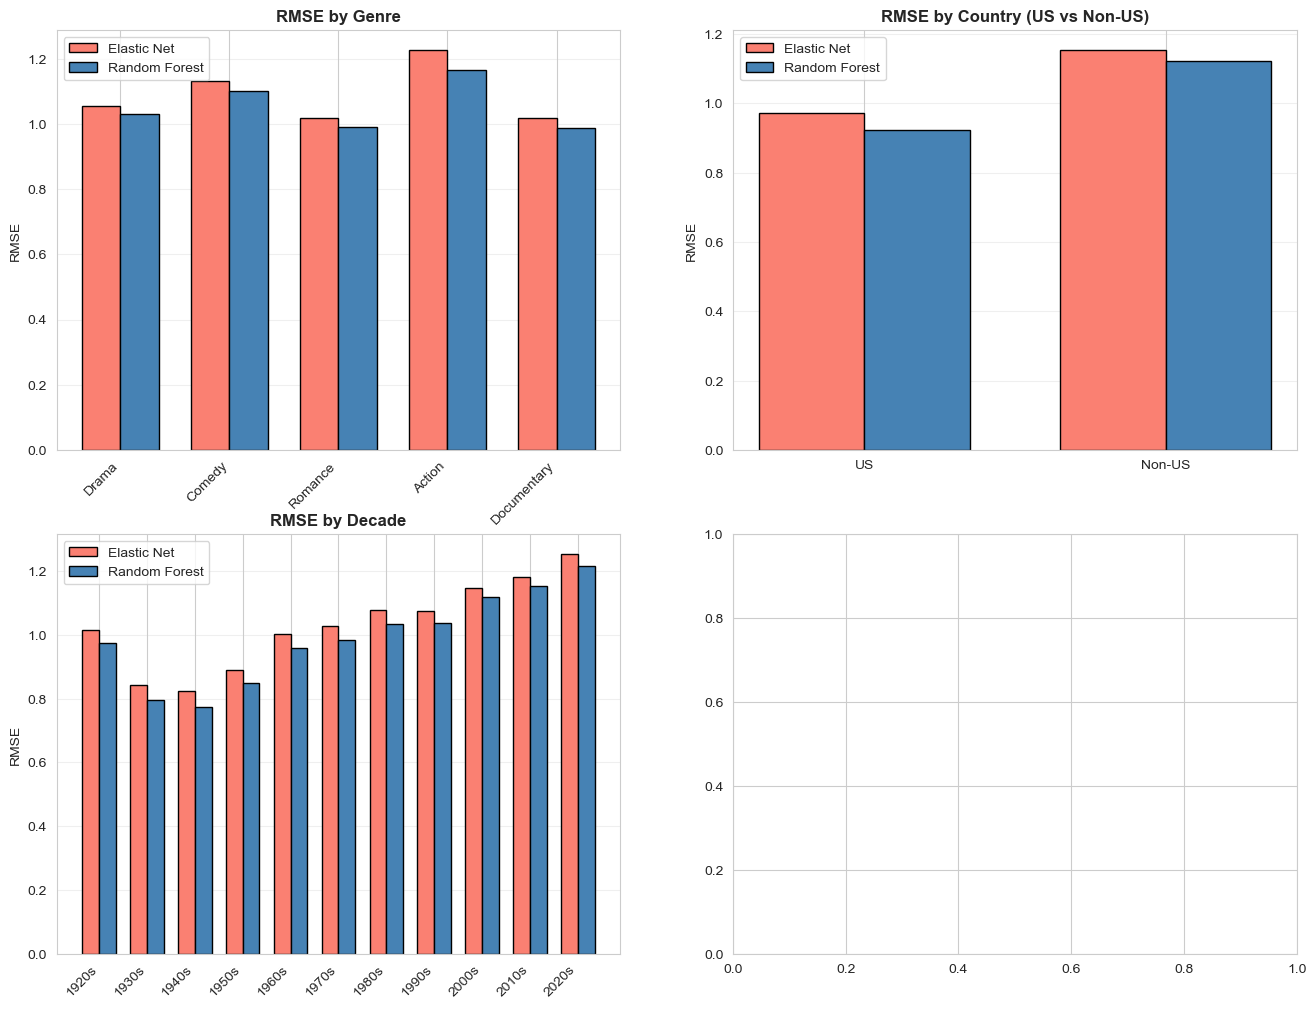

In [32]:
# ============================================================
# גרפים: ויזואליזציה של 4 החתכים
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# גרף 1: ז'אנר
ax1 = axes[0, 0]
x_pos = np.arange(len(genre_df))
width = 0.35
ax1.bar(x_pos - width/2, genre_df['RMSE (EN)'], width,
        label='Elastic Net', color='salmon', edgecolor='black')
ax1.bar(x_pos + width/2, genre_df['RMSE (RF)'], width,
        label='Random Forest', color='steelblue', edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(genre_df['ז\'אנר'], rotation=45, ha='right')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE by Genre', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# גרף 2: מדינה
ax2 = axes[0, 1]
x_pos = np.arange(len(country_df))
ax2.bar(x_pos - width/2, country_df['RMSE (EN)'], width,
        label='Elastic Net', color='salmon', edgecolor='black')
ax2.bar(x_pos + width/2, country_df['RMSE (RF)'], width,
        label='Random Forest', color='steelblue', edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(country_df['מדינה'])
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE by Country (US vs Non-US)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# גרף 3: עשור
ax3 = axes[1, 0]
x_pos = np.arange(len(decade_df))
ax3.bar(x_pos - width/2, decade_df['RMSE (EN)'], width,
        label='Elastic Net', color='salmon', edgecolor='black')
ax3.bar(x_pos + width/2, decade_df['RMSE (RF)'], width,
        label='Random Forest', color='steelblue', edgecolor='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(decade_df['עשור'], rotation=45, ha='right')
ax3.set_ylabel('RMSE')
ax3.set_title('RMSE by Decade', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

<div dir="rtl">

## 6. ניתוח הוגנות (Fairness Analysis)
<div dir="rtl">

בחנו האם מודל ה-Random Forest מציג ביצועים הוגנים על פני קבוצות שונות של סרטים, או שמא הוא מפלה לרעה תת-קבוצות מסוימות. עבור כל תת-קבוצה חישבנו את ה-RMSE וה-MAE בנפרד.

### 6.1 חתך לפי ז'אנר (5 הנפוצים ביותר)

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>ז'אנר</th><th>מס' סרטים</th><th>RMSE</th><th>MAE</th><th>הערכה</th></tr>
</thead>
<tbody>
<tr><td>Romance</td><td>11,005</td><td>0.9912</td><td>0.7505</td><td>הטוב ביותר</td></tr>
<tr><td>Documentary</td><td>9,103</td><td>0.9876</td><td>0.7352</td><td>טוב מאוד</td></tr>
<tr><td>Drama</td><td>40,964</td><td>1.0294</td><td>0.7830</td><td>טוב</td></tr>
<tr><td>Comedy</td><td>23,403</td><td>1.1010</td><td>0.8435</td><td>בינוני</td></tr>
<tr><td>Action</td><td>9,726</td><td>1.1640</td><td>0.8992</td><td>הגרוע ביותר</td></tr>
</tbody>
</table>

Documentary (0.9876) ו-Romance (0.9912) הם הז'אנרים שהמודל מתפקד בהם הכי טוב. Action הוא הז'אנר הקשה ביותר (RMSE=1.1640), כנראה בגלל הגיוון הגדול בתת-ז'אנרים - מסרטי גיבורי-על מיינסטרים ועד B-movies בתקציב נמוך. הפער בין הז'אנר הכי טוב לגרוע הוא כ-18%.

### 6.2 חתך לפי מדינה (US מול Non-US)

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>מדינה</th><th>מס' סרטים</th><th>RMSE</th><th>MAE</th></tr>
</thead>
<tbody>
<tr><td>US</td><td>14,827</td><td>0.9228</td><td>0.6944</td></tr>
<tr><td>Non-US</td><td>66,065</td><td>1.1210</td><td>0.8592</td></tr>
</tbody>
</table>

המודל מתפקד טוב יותר על סרטים אמריקאיים (RMSE=0.9228) מאשר על Non-US (RMSE=1.1210) - פער של כ-21%. ממצא זה מעניין במיוחד מאחר שיש פי 4.5 יותר סרטי Non-US בדאטה (66,065 לעומת 14,827). הסיבה הסבירה: התעשייה ההוליוודית אחידה יותר, עם פורמטים סטנדרטיים וקשרים מובהקים בין מטה-דאטה לדירוג. תעשיות הקולנוע הלא-אמריקאיות כוללות מגוון רחב של מסורות (בוליווד, סינמה אסיאתית, אירופאית) - כל אחת עם דינמיקות דירוג שונות.

### 6.3 חתך לפי עשור

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>עשור</th><th>מס' סרטים</th><th>RMSE</th><th>MAE</th></tr>
</thead>
<tbody>
<tr><td>1930s</td><td>2,190</td><td>0.7970</td><td>0.5927</td></tr>
<tr><td>1940s</td><td>2,359</td><td>0.7750</td><td>0.5857</td></tr>
<tr><td>1950s</td><td>3,165</td><td>0.8503</td><td>0.6510</td></tr>
<tr><td>1960s</td><td>4,350</td><td>0.9587</td><td>0.7481</td></tr>
<tr><td>1980s</td><td>6,759</td><td>1.0344</td><td>0.8114</td></tr>
<tr><td>2000s</td><td>12,257</td><td>1.1188</td><td>0.8534</td></tr>
<tr><td>2010s</td><td>23,567</td><td>1.1520</td><td>0.8756</td></tr>
<tr><td>2020s</td><td>12,712</td><td>1.2161</td><td>0.9282</td></tr>
</tbody>
</table>

הממצא הגדול ביותר בכל ניתוח ההוגנות: יש פער של כ-57% בין שנות ה-40 (RMSE=0.7750, הביצועים הטובים ביותר) לבין שנות ה-2020 (RMSE=1.2161, הגרועים ביותר). ככל שהסרט חדש יותר, הביצועים גרועים יותר.

<div dir="rtl">
הסיבות:
<div dir="rtl">

1. **Survivorship Bias** - סרטים ישנים ששרדו ב-IMDb הם בעיקר הקלאסיקות שזכרו, ולכן דירוגיהם יציבים וצפויים יותר.
<div dir="rtl">

2. **גיוון גדול בסרטים חדשים** - סרטים חדשים כוללים בלוקבאסטרים, סרטי B חובבניים, הפקות עצמאיות נישתיות, ותוכן סטרימינג. ההטרוגניות הזו קשה לחיזוי.
<div dir="rtl">

3. **כמות לא מסבירה** - ל-2010s יש 23,567 סרטים (הכי הרבה) אבל ביצועים גרועים. הבעיה בגיוון, לא בכמות.
<div dir="rtl">

### 6.4 דיון - חששות לשימוש בפועל
<div dir="rtl">
<div dir="rtl">
מתי לא לסמוך על החיזוי:
- סרט חדש (2020+) - RMSE של 1.22, פער של עד 1.2 נקודות
- סרט אקשן - שילוב של שני אזורי חולשה
- סרט Non-US מתעשייה נישתית
<div dir="rtl">
<div dir="rtl">
מתי כן לסמוך:
- קלאסיקה (1930s-1950s) - RMSE של 0.78-0.85
- סרט Romance או Documentary באיכות סטנדרטית
- סרט US מתעשייה הומוגנית
<div dir="rtl">

המסקנה: המודל יחסית הוגן בחתכי הז'אנר (פער 18%) והמדינה (פער 21%), אך מציג בעיית הוגנות משמעותית בחתך העשור (57%). הפער הגדול בעשור הוא תכונה של הדאטה (survivorship bias) ולא של המודל. עבור שימוש מסחרי, מומלץ להוסיף "אזהרת אמינות" לסרטים מהעשור הנוכחי.

</div>

<div dir="rtl">

## חלק 7: חשיבות פיצ'רים (Feature Importance)

### למה זה חשוב?

* **לעמוד באמינות המודל** - אם המודל "מאמין" בפיצ'רים שלא הגיוניים, יש בעיה
* **לקבל תובנות עסקיות** - מה באמת קובע דירוג סרט?
* **להשוות בין המודלים** - האם EN ו-RF "מסכימים" על מה חשוב?

### שתי שיטות שונות

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>מודל</th><th>שיטה</th><th>איך זה עובד?</th></tr>
</thead>
<tbody>
<tr>
<td>Elastic Net</td>
<td>מקדמים סטנדרטיים</td>
<td>גודל המקדם של כל פיצ'ר אומר כמה הוא משפיע. הסימן (חיובי/שלילי) אומר את כיוון ההשפעה.</td>
</tr>
<tr>
<td>Random Forest</td>
<td>Feature Importance מובנה</td>
<td>נמדד על ידי כמה כל פיצ'ר תורם להפחתת השגיאה ברחבי כל העצים.</td>
</tr>
</tbody>
</table>

הבדל חשוב: ב-EN נדע גם את כיוון ההשפעה (חיובי או שלילי), אבל ב-RF רק את מידת ההשפעה (כמה הוא חשוב).

</div>

מספר פיצ'רים ב-EN: 148
מספר פיצ'רים ב-RF: 142

🔵 Top 10 Features - Elastic Net (לפי גודל מקדם)


,feature,coefficient,abs_coefficient,direction
0,multilabel__genres=Documentary,+1.2381,1.2381,Positive
1,multilabel__genres=Horror,-0.8754,0.8754,Negative
2,multilabel__Language=Hindi,-0.6400,0.6400,Negative
3,multilabel__genres=Animation,+0.5255,0.5255,Positive
4,multilabel__genres=Action,-0.3971,0.3971,Negative
5,multilabel__genres=Sci-Fi,-0.3949,0.3949,Negative
6,multilabel__genres=Western,-0.3605,0.3605,Negative
7,multilabel__Language=Kannada,+0.3477,0.3477,Positive
8,multilabel__Language=Bengali,+0.2659,0.2659,Positive
9,multilabel__genres=Drama,+0.2603,0.2603,Positive



🟢 Top 10 Features - Random Forest (לפי Feature Importance)


,feature,importance
0,num__runtimeMinutes,0.1048
1,multilabel__genres=Documentary,0.1032
2,multilabel__genres=Horror,0.1001
3,num__screen_time_per_actor,0.0938
4,num__startYear,0.0705
5,num__actors_recent_movies_sum,0.0480
6,multilabel__genres=Drama,0.0459
7,num__actors_recent_movies_max,0.0426
8,multilabel__genres=Thriller,0.0217
9,multilabel__genres=Comedy,0.0205



🤝 השוואה: Top 5 של כל מודל

✅ פיצ'רים משותפים (2):
   • multilabel__genres=Documentary
   • multilabel__genres=Horror

🔵 ייחודיים ל-EN (3):
   • multilabel__genres=Action
   • multilabel__genres=Animation
   • multilabel__Language=Hindi

🟢 ייחודיים ל-RF (3):
   • num__runtimeMinutes
   • num__startYear
   • num__screen_time_per_actor


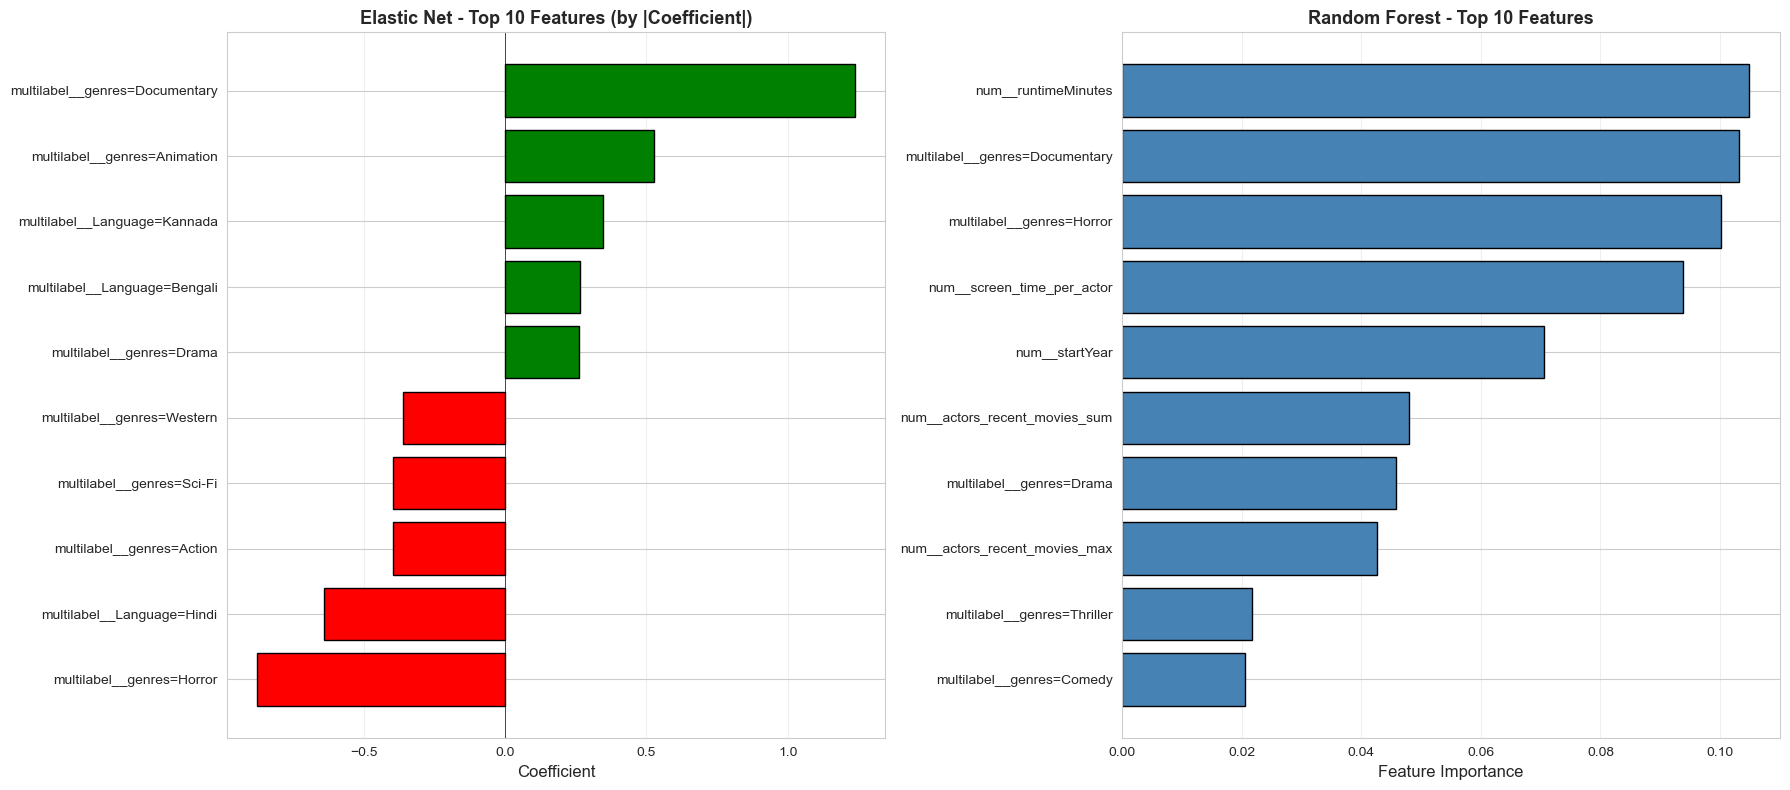

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# שלב 1: שמות הפיצ'רים מה-Pipeline
# ============================================================
en_feature_names = best_en.named_steps['preprocessor'].get_feature_names_out()
rf_feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

print(f"מספר פיצ'רים ב-EN: {len(en_feature_names)}")
print(f"מספר פיצ'רים ב-RF: {len(rf_feature_names)}")

# ============================================================
# שלב 2: Elastic Net - מקדמים
# ============================================================
en_coefs = best_en.named_steps['model'].coef_

en_importance = pd.DataFrame({
    'feature': en_feature_names,
    'coefficient': en_coefs,
    'abs_coefficient': np.abs(en_coefs),
    'direction': ['Positive' if c > 0 else 'Negative' for c in en_coefs],
})
en_importance = en_importance.sort_values('abs_coefficient', ascending=False)

print("\n" + "=" * 70)
print("🔵 Top 10 Features - Elastic Net (לפי גודל מקדם)")
print("=" * 70)

top_en = en_importance.head(10).reset_index(drop=True)
display(top_en.style.format({
    'coefficient': '{:+.4f}',
    'abs_coefficient': '{:.4f}',
}).background_gradient(subset=['coefficient'], cmap='RdYlGn', vmin=-0.5, vmax=0.5)
   .set_caption("Top 10 פיצ'רים - Elastic Net"))

# ============================================================
# שלב 3: Random Forest - Feature Importance
# ============================================================
rf_importances = best_rf.named_steps['model'].feature_importances_

rf_importance = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': rf_importances,
})
rf_importance = rf_importance.sort_values('importance', ascending=False)

print("\n" + "=" * 70)
print("🟢 Top 10 Features - Random Forest (לפי Feature Importance)")
print("=" * 70)

top_rf = rf_importance.head(10).reset_index(drop=True)
display(top_rf.style.format({
    'importance': '{:.4f}',
}).background_gradient(subset=['importance'], cmap='Greens')
   .set_caption("Top 10 פיצ'רים - Random Forest"))

# ============================================================
# שלב 4: השוואה - מי מסכים על מי?
# ============================================================
top_5_en = set(top_en.head(5)['feature'].tolist())
top_5_rf = set(top_rf.head(5)['feature'].tolist())

common = top_5_en & top_5_rf
only_en = top_5_en - top_5_rf
only_rf = top_5_rf - top_5_en

print("\n" + "=" * 70)
print("🤝 השוואה: Top 5 של כל מודל")
print("=" * 70)
print(f"\n✅ פיצ'רים משותפים ({len(common)}):")
for f in common:
    print(f"   • {f}")
print(f"\n🔵 ייחודיים ל-EN ({len(only_en)}):")
for f in only_en:
    print(f"   • {f}")
print(f"\n🟢 ייחודיים ל-RF ({len(only_rf)}):")
for f in only_rf:
    print(f"   • {f}")

# ============================================================
# שלב 5: גרפים
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# גרף 1: Top 10 EN
ax1 = axes[0]
top_10_en = en_importance.head(10).sort_values('coefficient')
colors = ['green' if c > 0 else 'red' for c in top_10_en['coefficient']]
ax1.barh(range(len(top_10_en)), top_10_en['coefficient'],
         color=colors, edgecolor='black')
ax1.set_yticks(range(len(top_10_en)))
ax1.set_yticklabels(top_10_en['feature'], fontsize=10)
ax1.axvline(0, color='black', linewidth=0.5)
ax1.set_xlabel('Coefficient', fontsize=12)
ax1.set_title('Elastic Net - Top 10 Features (by |Coefficient|)',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# גרף 2: Top 10 RF
ax2 = axes[1]
top_10_rf = rf_importance.head(10).sort_values('importance')
ax2.barh(range(len(top_10_rf)), top_10_rf['importance'],
         color='steelblue', edgecolor='black')
ax2.set_yticks(range(len(top_10_rf)))
ax2.set_yticklabels(top_10_rf['feature'], fontsize=10)
ax2.set_xlabel('Feature Importance', fontsize=12)
ax2.set_title('Random Forest - Top 10 Features',
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


<div dir="rtl">

## 7. ניתוח חשיבות פיצ'רים
<div dir="rtl">
<div dir="rtl">
מספר הפיצ'רים: 148 ב-Elastic Net, 142 ב-Random Forest.

### Top 10 - Elastic Net (לפי גודל מקדם)

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>#</th><th>פיצ'ר</th><th>מקדם</th><th>כיוון</th></tr>
</thead>
<tbody>
<tr><td>1</td><td>genres=Documentary</td><td>+1.2381</td><td>Positive</td></tr>
<tr><td>2</td><td>genres=Horror</td><td>-0.8754</td><td>Negative</td></tr>
<tr><td>3</td><td>Language=Hindi</td><td>-0.6400</td><td>Negative</td></tr>
<tr><td>4</td><td>genres=Animation</td><td>+0.5255</td><td>Positive</td></tr>
<tr><td>5</td><td>genres=Action</td><td>-0.3971</td><td>Negative</td></tr>
</tbody>
</table>

### Top 10 - Random Forest (לפי Feature Importance)

<table dir="rtl" style="text-align: right; width: 100%;">
<thead>
<tr><th>#</th><th>פיצ'ר</th><th>חשיבות</th><th>סוג</th></tr>
</thead>
<tbody>
<tr><td>1</td><td>runtimeMinutes</td><td>0.1048</td><td>נומרי</td></tr>
<tr><td>2</td><td>genres=Documentary</td><td>0.1032</td><td>קטגוריאלי</td></tr>
<tr><td>3</td><td>genres=Horror</td><td>0.1001</td><td>קטגוריאלי</td></tr>
<tr><td>4</td><td>screen_time_per_actor</td><td>0.0938</td><td>נומרי (הנדסי)</td></tr>
<tr><td>5</td><td>startYear</td><td>0.0705</td><td>נומרי</td></tr>
</tbody>
</table>
<div dir="rtl">
פיצ'רים משותפים ב-Top 5: Documentary ו-Horror. ההסכמה בין שני מודלים שונים מהותית מעידה על תופעות אמיתיות בדאטה.

</div>

<div dir="rtl">

## בדיקת תקינות לתחרות

התא הבא מסמלץ בדיוק את הקוד שהמרצה יריץ לבדיקת התחרות. הוא טוען את `model.pkl`, מריץ את `prepare_data`, ומחשב את המדדים. אם התא רץ ללא שגיאות - המודל מוכן לתחרות.

</div>

In [34]:
# ============================================================
# בדיקת תקינות לתחרות - סימולציה של הקוד שהמרצה יריץ
# ============================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# שלב 1: קריאת הדאטה (המרצה יקרא ל-train.csv)
df_check = pd.read_csv('dataset.csv', low_memory=False)
y_check = df_check['averageRating']

# שלב 2: הרצת prepare_data
X_check = prepare_data(df_check)
print(f'✅ prepare_data רצה - {X_check.shape[0]} שורות, {X_check.shape[1]} עמודות')

# שלב 3: סינון שורות עם y תקין
mask = y_check.notna()
X_check = X_check[mask].reset_index(drop=True)
y_check = y_check[mask].reset_index(drop=True)

# שלב 4: טעינת המודל - בדיוק כמו המרצה
try:
    import joblib
    model = joblib.load('model.pkl')
except Exception:
    import pickle
    with open('model.pkl', 'rb') as f:
        model = pickle.load(f)
print('✅ model.pkl נטען')

# שלב 5: חיזוי
y_pred = model.predict(X_check)

# שלב 6: חישוב מדדים
metrics = pd.DataFrame([{
    'RMSE': np.sqrt(mean_squared_error(y_check, y_pred)),
    'MAE':  mean_absolute_error(y_check, y_pred),
    'R2':   r2_score(y_check, y_pred),
}])

print('\n📊 תוצאות:')
print(metrics.to_string(index=False))

✅ prepare_data רצה - 133884 שורות, 23 עמודות
✅ model.pkl נטען

📊 תוצאות:
    RMSE      MAE       R2
1.121575 0.857824 0.247343

🎯 אם הגעת לכאן ללא שגיאות - המודל מוכן לתחרות!
